## Libraries + Import

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

from pathlib import Path
import os
import pandas as pd
import random
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from collections import Counter
import numpy as np
import cv2
from tqdm.auto import tqdm
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
from torchmetrics.classification import BinaryAccuracy, BinaryF1Score, BinaryAUROC
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget, ClassifierOutputTarget

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

In [7]:
SEED = 22

pl.seed_everything(SEED, workers=True)

PROJECT_ROOT = Path.cwd().parent

DATASET_PATH = PROJECT_ROOT / "datasets" / "faceforensics++_test"

TRAIN_PATH = DATASET_PATH / "train"
VAL_PATH = DATASET_PATH / "val"
TEST_PATH = DATASET_PATH / "test"

CLASSES = [
    "Original",
    "Deepfakes",
    "Face2Face",
    "FaceShifter",
    "FaceSwap",
    "NeuralTextures"
]

NUM_CLASSES = len(CLASSES)

print(DATASET_PATH)
print(TRAIN_PATH)
print(VAL_PATH)
print(TEST_PATH)

Seed set to 22


c:\Users\tomma\DeepfakeSII\datasets\faceforensics++_test
c:\Users\tomma\DeepfakeSII\datasets\faceforensics++_test\train
c:\Users\tomma\DeepfakeSII\datasets\faceforensics++_test\val
c:\Users\tomma\DeepfakeSII\datasets\faceforensics++_test\test


## Dataset Sanity Check

In [46]:
def count_images_in_split(split_path, split_name):

    rows = []

    for class_name in CLASSES:
        class_path = split_path / class_name
        count = 0
        for image_path in class_path.glob("*.png"):
            count += 1
        rows.append({"split": split_name, "class": class_name, "images": count})
    return rows

In [47]:
rows = []
for row in count_images_in_split(TRAIN_PATH, "train"): rows.append(row)
for row in count_images_in_split(VAL_PATH, "val"): rows.append(row)
for row in count_images_in_split(TEST_PATH, "test"): rows.append(row)

counts_df = pd.DataFrame(rows)
counts_df

,split,class,images
0,train,Original,19372
1,train,Deepfakes,19315
2,train,Face2Face,19383
3,train,FaceShifter,19378
4,train,FaceSwap,19344
5,train,NeuralTextures,19378
6,val,Original,1391
7,val,Deepfakes,1386
8,val,Face2Face,1393
9,val,FaceShifter,1392


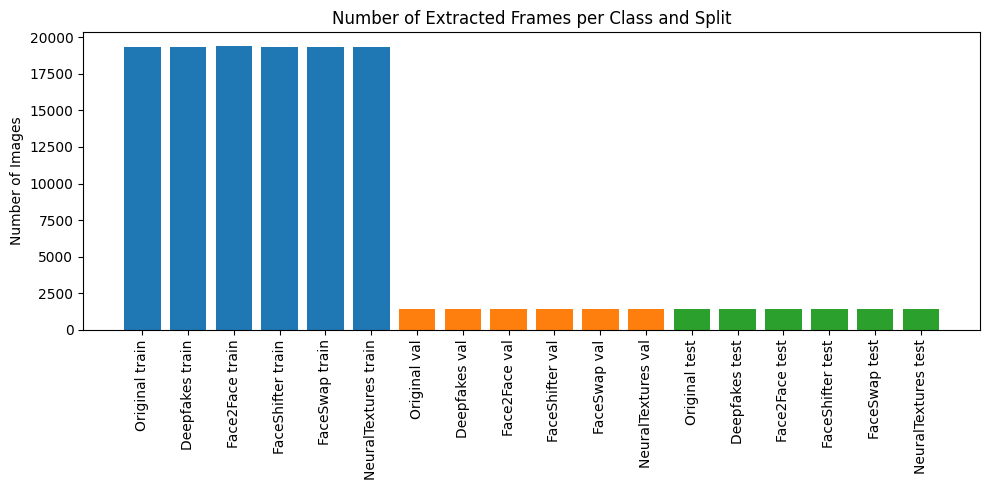

In [48]:
plt.figure(figsize=(10, 5))

for split_name in ["train", "val", "test"]:
    split_df = counts_df[counts_df["split"] == split_name]
    plt.bar(split_df["class"] + " " + split_name, split_df["images"], label=split_name)

plt.xticks(rotation=90)
plt.title("Number of Extracted Frames per Class and Split")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

## Model

In [8]:
# assign fixed index to each class
class FixedClassImageFolder(ImageFolder):

    def __init__(self, root, class_names, transform=None):
        self.class_names = class_names
        super().__init__(root=root, transform=transform)

    def find_classes(self, directory):
        classes = []
        class_to_idx = {}

        for class_index, class_name in enumerate(self.class_names):
            class_path = Path(directory) / class_name
            if not class_path.exists():
                raise FileNotFoundError(f"Missing class folder: {class_path}")

            classes.append(class_name)
            class_to_idx[class_name] = class_index

        return classes, class_to_idx

In [9]:
# Deepfakes_000_003_sample_004_frame_000123.png -> 000_003
def extract_video_key_from_frame_path(frame_path, class_name):
    stem = Path(frame_path).stem
    prefix = class_name + "_"

    if stem.startswith(prefix):
        stem = stem[len(prefix):]

    video_key = stem.split("_sample_")[0]

    return video_key

In [10]:
class FaceForensicsDataModule(pl.LightningDataModule):

    def __init__(self, train_path, val_path, test_path, class_names, batch_size=64, num_workers=0, train_n_frames_per_video=None, val_n_frames_per_video=None, subset_seed=22):

        super().__init__()

        self.train_path = train_path
        self.val_path = val_path
        self.test_path = test_path

        self.class_names = class_names

        self.batch_size = batch_size
        self.num_workers = num_workers

        # number of frames to sample per video, for train and validation
        self.train_n_frames_per_video = train_n_frames_per_video
        self.val_n_frames_per_video = val_n_frames_per_video

        self.subset_seed = subset_seed

        self.train_transform = T.Compose([
            T.Resize((224, 224)),
            T.RandomHorizontalFlip(p=0.5), # augmentation
            T.ToTensor(),
            T.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

        self.eval_transform = T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])


    def _subset_frames_per_video(self, dataset, n_frames_per_video=None):

        # return full dataset if no frame limit is requested
        if n_frames_per_video is None:
            return dataset

        # check that the requested number of frames is valid
        if n_frames_per_video < 1:
            raise ValueError("n_frames_per_video must be at least 1 or None.")

        rng = random.Random(self.subset_seed)

        # create one dictionary of videos for each class
        videos_by_class = {}

        for class_index in range(len(self.class_names)):
            videos_by_class[class_index] = {}

        # group frame indices by class and video key
        for index, sample in enumerate(dataset.samples):

            frame_path, label = sample
            class_name = self.class_names[label]

            video_key = extract_video_key_from_frame_path(frame_path, class_name)

            if video_key not in videos_by_class[label]:
                videos_by_class[label][video_key] = []

            videos_by_class[label][video_key].append(index)

        # store the selected frame indices
        selected_indices = []

        # sample the requested number of frames from each video
        for class_index in range(len(self.class_names)):

            for video_key in videos_by_class[class_index]:

                frame_indices = videos_by_class[class_index][video_key]

                # if the video has fewer frames than requested, keep all available frames
                n_frames = n_frames_per_video

                if n_frames > len(frame_indices):
                    n_frames = len(frame_indices)

                sampled_indices = rng.sample(frame_indices, n_frames)

                for index in sampled_indices:
                    selected_indices.append(index)

        rng.shuffle(selected_indices)

        return Subset(dataset, selected_indices)


    def _count_labels(self, dataset):
        counts = Counter()
        if isinstance(dataset, Subset):
            base_dataset = dataset.dataset
            for index in dataset.indices:
                _, label = base_dataset.samples[index]
                counts[label] += 1
        else:
            for _, label in dataset.samples:
                counts[label] += 1

        return counts


    def setup(self, stage=None):

        self.train_dataset = FixedClassImageFolder(root=self.train_path, class_names=self.class_names, transform=self.train_transform)
        self.val_dataset = FixedClassImageFolder(root=self.val_path, class_names=self.class_names, transform=self.eval_transform)
        self.test_dataset = FixedClassImageFolder(root=self.test_path, class_names=self.class_names, transform=self.eval_transform)

        self.train_dataset = self._subset_frames_per_video(self.train_dataset, n_frames_per_video=self.train_n_frames_per_video)
        self.val_dataset = self._subset_frames_per_video(self.val_dataset, n_frames_per_video=self.val_n_frames_per_video)
        # keep full test set

        dataset_ref = self.train_dataset.dataset if isinstance(self.train_dataset, Subset) else self.train_dataset

        print("Class mapping:", dataset_ref.class_to_idx)

        print(f"Train: {len(self.train_dataset)}")
        print(f"Validation: {len(self.val_dataset)}")
        print(f"Test: {len(self.test_dataset)}")

        print("\nTrain counts:")
        self._print_counts(self.train_dataset)

        print("\nValidation counts:")
        self._print_counts(self.val_dataset)

        print("\nTest counts:")
        self._print_counts(self.test_dataset)


    def _print_counts(self, dataset):
        counts = self._count_labels(dataset)
        for class_index in range(len(self.class_names)):
            class_name = self.class_names[class_index]
            print(f"{class_name}: {counts[class_index]}")


    def train_dataloader(self):

        persistent_workers = False

        if self.num_workers > 0:
            persistent_workers = True

        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            persistent_workers=persistent_workers
        )


    def val_dataloader(self):

        persistent_workers = False

        if self.num_workers > 0:
            persistent_workers = True

        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            persistent_workers=persistent_workers
        )


    def test_dataloader(self):

        persistent_workers = False

        if self.num_workers > 0:
            persistent_workers = True

        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            persistent_workers=persistent_workers
        )

In [11]:
data_module = FaceForensicsDataModule(
    train_path=TRAIN_PATH,
    val_path=VAL_PATH,
    test_path=TEST_PATH,
    class_names=CLASSES,
    batch_size=64,
    num_workers=0,
    train_n_frames_per_video=3,
    val_n_frames_per_video=1,
    subset_seed=SEED
)

data_module.setup()

Class mapping: {'Original': 0, 'Deepfakes': 1, 'Face2Face': 2, 'FaceShifter': 3, 'FaceSwap': 4, 'NeuralTextures': 5}
Train: 4308
Validation: 832
Test: 83113

Train counts:
Original: 717
Deepfakes: 717
Face2Face: 719
FaceShifter: 720
FaceSwap: 719
NeuralTextures: 716

Validation counts:
Original: 139
Deepfakes: 138
Face2Face: 139
FaceShifter: 139
FaceSwap: 138
NeuralTextures: 139

Test counts:
Original: 13864
Deepfakes: 13763
Face2Face: 13908
FaceShifter: 13822
FaceSwap: 13851
NeuralTextures: 13905


In [12]:
def get_video_frame_counts(dataset, class_names):

        rows = []

        if isinstance(dataset, Subset):
            base_dataset = dataset.dataset

            for index in dataset.indices:
                frame_path, label = base_dataset.samples[index]
                class_name = class_names[label]
                video_key = extract_video_key_from_frame_path(frame_path, class_name)
                rows.append({"class": class_name, "video_key": video_key, "frame_path": frame_path})

        else:
            for frame_path, label in dataset.samples:
                class_name = class_names[label]
                video_key = extract_video_key_from_frame_path(frame_path, class_name)
                rows.append({"class": class_name, "video_key": video_key, "frame_path": frame_path})

        frames_df = pd.DataFrame(rows)

        # count frames per video
        video_counts_df = (frames_df.groupby(["class", "video_key"]).size().reset_index(name="n_frames"))

        return video_counts_df
    

def show_video_frame_count_summary(video_counts_df, split_name):

    print(f"\n{split_name.upper()}")

    # Show min, max, mean and number of videos for each class
    summary_df = (video_counts_df.groupby("class")["n_frames"].agg(["count", "min", "max", "mean"]).reset_index())
    display(summary_df)

    # Show how many videos have 1 frame, 2 frames, 3 frames, etc.
    count_distribution = pd.crosstab(video_counts_df["class"], video_counts_df["n_frames"])

    display(count_distribution)

train_video_counts = get_video_frame_counts(data_module.train_dataset, CLASSES)
val_video_counts = get_video_frame_counts(data_module.val_dataset, CLASSES)
test_video_counts = get_video_frame_counts(data_module.test_dataset, CLASSES)

show_video_frame_count_summary(train_video_counts, "train")
show_video_frame_count_summary(val_video_counts, "val")
show_video_frame_count_summary(test_video_counts, "test")


TRAIN


,class,count,min,max,mean
0,Deepfakes,717,1,1,1.0
1,Face2Face,719,1,1,1.0
2,FaceShifter,720,1,1,1.0
3,FaceSwap,719,1,1,1.0
4,NeuralTextures,716,1,1,1.0
5,Original,717,1,1,1.0


n_frames,1
class,
Deepfakes,717
Face2Face,719
FaceShifter,720
FaceSwap,719
NeuralTextures,716
Original,717



VAL


,class,count,min,max,mean
0,Deepfakes,138,1,1,1.0
1,Face2Face,139,1,1,1.0
2,FaceShifter,139,1,1,1.0
3,FaceSwap,138,1,1,1.0
4,NeuralTextures,139,1,1,1.0
5,Original,139,1,1,1.0


n_frames,1
class,
Deepfakes,138
Face2Face,139
FaceShifter,139
FaceSwap,138
NeuralTextures,139
Original,139



TEST


,class,count,min,max,mean
0,Deepfakes,140,15,100,98.307143
1,Face2Face,140,57,100,99.342857
2,FaceShifter,140,34,100,98.728571
3,FaceSwap,140,37,100,98.935714
4,NeuralTextures,140,62,100,99.321429
5,Original,140,47,100,99.028571


n_frames,15,34,37,41,47,52,55,57,62,69,...,90,92,93,94,95,96,97,98,99,100
class,,,,,,,,,,,,,,,,,,,,,
Deepfakes,1,0,0,1,0,0,0,0,1,0,...,1,0,1,1,2,1,0,1,1,128
Face2Face,0,0,0,0,0,0,0,1,0,0,...,0,1,0,0,1,0,1,1,2,132
FaceShifter,0,1,0,0,0,0,1,0,0,1,...,0,1,0,1,0,0,1,0,7,126
FaceSwap,0,0,1,0,1,0,0,0,0,0,...,0,0,0,2,1,1,2,1,4,127
NeuralTextures,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,1,1,1,0,4,130
Original,0,0,0,0,1,1,0,0,0,0,...,1,0,0,0,0,1,2,0,4,129


In [13]:
class FaceForensicsResNet18(pl.LightningModule):

    def __init__(self, num_classes=6, learning_rate=1e-4, weight_decay=1e-4):
        super().__init__()

        self.save_hyperparameters()

        self.num_classes = num_classes
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay

        weights = ResNet18_Weights.DEFAULT
        self.model = resnet18(weights=weights)

        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes) # attach classifier to pretrained CNN

        self.train_acc = MulticlassAccuracy(num_classes=num_classes, average="micro")
        self.val_acc = MulticlassAccuracy(num_classes=num_classes, average="micro")
        self.test_acc = MulticlassAccuracy(num_classes=num_classes, average="micro")

        self.train_macro_f1 = MulticlassF1Score(num_classes=num_classes, average="macro")
        self.val_macro_f1 = MulticlassF1Score(num_classes=num_classes, average="macro")
        self.test_macro_f1 = MulticlassF1Score(num_classes=num_classes, average="macro")

    def forward(self, x):
        logits = self.model(x)
        return logits

    def training_step(self, batch, batch_idx):

        images, labels = batch
        logits = self(images)

        loss = F.cross_entropy(logits, labels)
        preds = torch.argmax(logits, dim=1)

        self.train_acc.update(preds, labels)
        self.train_macro_f1.update(preds, labels)

        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("train_acc", self.train_acc, prog_bar=True, on_step=False, on_epoch=True)
        self.log("train_macro_f1", self.train_macro_f1, prog_bar=False, on_step=False, on_epoch=True)

        return loss

    def validation_step(self, batch, batch_idx):

        images, labels = batch
        logits = self(images)

        loss = F.cross_entropy(logits, labels)
        preds = torch.argmax(logits, dim=1)

        self.val_acc.update(preds, labels)
        self.val_macro_f1.update(preds, labels)

        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("val_acc", self.val_acc, prog_bar=True, on_step=False, on_epoch=True)
        self.log("val_macro_f1", self.val_macro_f1, prog_bar=True, on_step=False, on_epoch=True)

        return loss

    def test_step(self, batch, batch_idx):

        images, labels = batch
        logits = self(images)

        loss = F.cross_entropy(logits, labels)
        preds = torch.argmax(logits, dim=1)

        self.test_acc.update(preds, labels)
        self.test_macro_f1.update(preds, labels)

        self.log("test_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("test_acc", self.test_acc, prog_bar=True, on_step=False, on_epoch=True)
        self.log("test_macro_f1", self.test_macro_f1, prog_bar=True, on_step=False, on_epoch=True)

        return loss

    def configure_optimizers(self):

        return torch.optim.AdamW(
            self.parameters(),
            lr=self.learning_rate,
            weight_decay=self.weight_decay
        )

In [14]:
model = FaceForensicsResNet18(
    num_classes=NUM_CLASSES,
    learning_rate=1e-4,
    weight_decay=1e-4
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=7,
    verbose=True
)

checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    filename="resnet18_multi_0.05"
)

logger = TensorBoardLogger(
    save_dir="lightning_logs",
    name="ff++_resnet18_multi_0.05"
)

In [98]:
from torchinfo import summary

summary(
    model,
    input_size=(1, 3, 224, 224), # (batch, channels, H, W)
    col_names=["input_size", "output_size", "num_params"]
)

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #
FaceForensicsResNet18                         [1, 3, 224, 224]          [1, 6]                    --
├─ResNet: 1-1                                 [1, 3, 224, 224]          [1, 6]                    --
│    └─Conv2d: 2-1                            [1, 3, 224, 224]          [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                       [1, 64, 112, 112]         [1, 64, 112, 112]         128
│    └─ReLU: 2-3                              [1, 64, 112, 112]         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [1, 64, 112, 112]         [1, 64, 56, 56]           --
│    └─Sequential: 2-5                        [1, 64, 56, 56]           [1, 64, 56, 56]           --
│    │    └─BasicBlock: 3-1                   [1, 64, 56, 56]           [1, 64, 56, 56]           73,984
│    │    └─BasicBlock: 3-2                   [1, 64, 56, 56]           [1, 64

In [15]:
precision = "32-true"
if torch.cuda.is_available():
    precision = "16-mixed"

In [16]:
trainer = pl.Trainer(
    max_epochs=50,
    callbacks=[
        early_stopping,
        checkpoint_callback
    ],
    accelerator="auto",
    devices="auto",
    precision=precision,
    logger=logger,
    enable_progress_bar=True
)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [67]:
trainer.fit(model, datamodule=data_module)

You are using a CUDA device ('NVIDIA RTX 500 Ada Generation Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\tomma\anaconda3\envs\py310\lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name           | Type               | Params | Mode 
--------------------------------------------------------------
0 | model          | ResNet             | 11.2 M | train
1 | train_acc      | MulticlassAccuracy | 0      | train
2 | val_acc        | MulticlassAccuracy | 0      | train
3 | test_acc       | MulticlassAccur

Class mapping: {'Original': 0, 'Deepfakes': 1, 'Face2Face': 2, 'FaceShifter': 3, 'FaceSwap': 4, 'NeuralTextures': 5}
Train: 12960
Validation: 840
Test: 839

Train counts:
Original: 2160
Deepfakes: 2160
Face2Face: 2160
FaceShifter: 2160
FaceSwap: 2160
NeuralTextures: 2160

Validation counts:
Original: 140
Deepfakes: 140
Face2Face: 140
FaceShifter: 140
FaceSwap: 140
NeuralTextures: 140

Test counts:
Original: 140
Deepfakes: 139
Face2Face: 140
FaceShifter: 140
FaceSwap: 140
NeuralTextures: 140


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\tomma\anaconda3\envs\py310\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.
c:\Users\tomma\anaconda3\envs\py310\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 7 records. Best score: 0.333. Signaling Trainer to stop.


## Results

In [ ]:
#torch.save(model.state_dict(), "nonsisamai.pth")

In [46]:
from pathlib import Path
best_model_path = Path(r"C:\Users\tomma\DeepfakeSII\outputs_hpc_ffpp\checkpoints\ffpp__multiclass__resnet18__subset_None__frames_train_100__frames_val_100\best.ckpt")
best_model = FaceForensicsResNet18.load_from_checkpoint(checkpoint_path=str(best_model_path))
best_model.eval()

c:\Users\tomma\anaconda3\envs\py310\lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.6.5, which is newer than your current Lightning version: v2.5.5


FaceForensicsResNet18(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tru

### Training curves

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

In [2]:
def load_tensorboard_metrics(log_dir):

    event_acc = EventAccumulator(str(log_dir))
    event_acc.Reload()

    metrics = {}

    for tag in event_acc.Tags()["scalars"]:

        events = event_acc.Scalars(tag)

        metrics[tag] = {
            "steps": [x.step for x in events],
            "values": [x.value for x in events]
        }

    return metrics

In [12]:
def is_valid_training_run(metrics):

    old_to_new_metric_names = {
        "train_loss": "train_loss_epoch",
        "train_acc": "train_acc_epoch"
    }

    for old_name, new_name in old_to_new_metric_names.items():

        if old_name in metrics:

            if new_name not in metrics:
                metrics[new_name] = metrics[old_name]

            del metrics[old_name]

    required_metrics = [
        "val_loss",
        "val_acc",
        "train_loss_epoch",
        "train_acc_epoch"
    ]

    for metric_name in required_metrics:

        if metric_name not in metrics:
            return False

        if len(metrics[metric_name]["values"]) == 0:
            return False

    return True

In [13]:
def find_valid_versions(run_dir):

    run_dir = Path(run_dir)

    valid_versions = []

    for version_dir in sorted(run_dir.glob("version_*")):

        metrics = load_tensorboard_metrics(version_dir)

        if is_valid_training_run(metrics):

            best_val_acc = max(metrics["val_acc"]["values"])
            last_val_acc = metrics["val_acc"]["values"][-1]
            n_epochs = len(metrics["val_acc"]["values"])

            has_test = "test_acc" in metrics

            valid_versions.append({
                "version_dir": version_dir,
                "best_val_acc": best_val_acc,
                "last_val_acc": last_val_acc,
                "n_epochs": n_epochs,
                "has_test": has_test
            })

    return valid_versions

In [14]:
def print_valid_versions(run_dir):

    valid_versions = find_valid_versions(run_dir)

    for i, version in enumerate(valid_versions):

        print("INDEX:", i)
        print("VERSION:", version["version_dir"])
        print("BEST VAL ACC:", version["best_val_acc"])
        print("LAST VAL ACC:", version["last_val_acc"])
        print("EPOCHS:", version["n_epochs"])
        print("HAS TEST:", version["has_test"])
        print()

In [15]:
print_valid_versions("../outputs_hpc_ffpp/logs/ffpp__multiclass__resnet18__subset_None__frames_train_100__frames_val_100")

INDEX: 0
VERSION: ..\outputs_hpc_ffpp\logs\ffpp__multiclass__resnet18__subset_None__frames_train_100__frames_val_100\version_0
BEST VAL ACC: 0.9388542175292969
LAST VAL ACC: 0.9323144555091858
EPOCHS: 26
HAS TEST: False



In [17]:
def find_best_version(run_dir):

    valid_versions = find_valid_versions(run_dir)

    if len(valid_versions) == 0:
        return None

    best_version = max(valid_versions, key=lambda x: x["best_val_acc"])

    return best_version

In [19]:
def get_epoch_axis(metrics, metric_name):

    values = metrics[metric_name]["values"]

    epochs = []

    for i in range(len(values)):
        epochs.append(i + 1)

    return epochs

In [23]:
def normalize_metric_names(metrics):

    old_to_new_metric_names = {
        "train_loss": "train_loss_epoch",
        "train_acc": "train_acc_epoch"
    }

    for old_name, new_name in old_to_new_metric_names.items():

        if old_name in metrics:

            if new_name not in metrics:
                metrics[new_name] = metrics[old_name]

    return metrics

In [ ]:
def plot_single_training_curves(log_dir, title):

    metrics = load_tensorboard_metrics(log_dir)
    metrics = normalize_metric_names(metrics)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    train_loss_epochs = get_epoch_axis(metrics, "train_loss_epoch")
    val_loss_epochs = get_epoch_axis(metrics, "val_loss")

    train_acc_epochs = get_epoch_axis(metrics, "train_acc_epoch")
    val_acc_epochs = get_epoch_axis(metrics, "val_acc")

    axes[0].plot(train_loss_epochs, metrics["train_loss_epoch"]["values"], label="Train Loss")
    axes[0].plot(val_loss_epochs, metrics["val_loss"]["values"], label="Validation Loss")

    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(train_acc_epochs, metrics["train_acc_epoch"]["values"], label="Train Accuracy")
    axes[1].plot(val_acc_epochs, metrics["val_acc"]["values"], label="Validation Accuracy")

    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid()

    fig.suptitle(title)

    plt.tight_layout()
    plt.show()

#### Plots for Multiclass

{'version_dir': WindowsPath('../outputs_hpc_ffpp/logs/ffpp__multiclass__resnet18__subset_None__frames_train_100__frames_val_100/version_0'), 'best_val_acc': 0.9388542175292969, 'last_val_acc': 0.9323144555091858, 'n_epochs': 26, 'has_test': False}


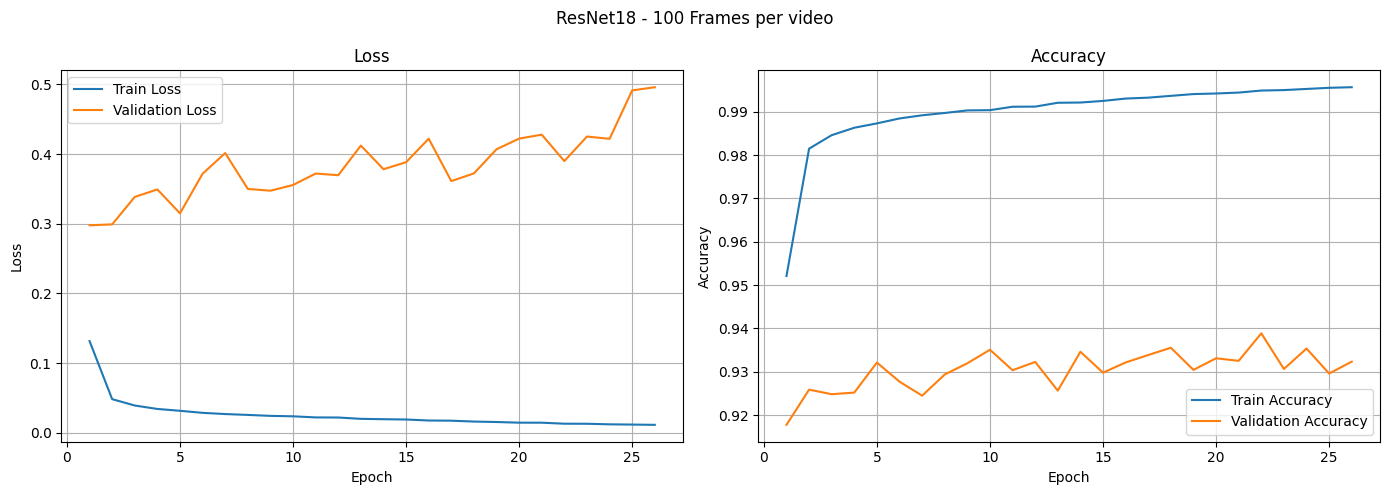

In [21]:
run_dir = "../outputs_hpc_ffpp/logs/ffpp__multiclass__resnet18__subset_None__frames_train_100__frames_val_100"
best_version = find_best_version(run_dir)
print(best_version)
log_dir = best_version["version_dir"]
plot_single_training_curves(log_dir, title="ResNet18 - 100 Frames per video")

{'version_dir': WindowsPath('../outputs_hpc_ffpp/logs/ffpp__multiclass__resnet18__subset_None__frames_train_10__frames_val_10/version_0'), 'best_val_acc': 0.925000011920929, 'last_val_acc': 0.9202380776405334, 'n_epochs': 26, 'has_test': False}


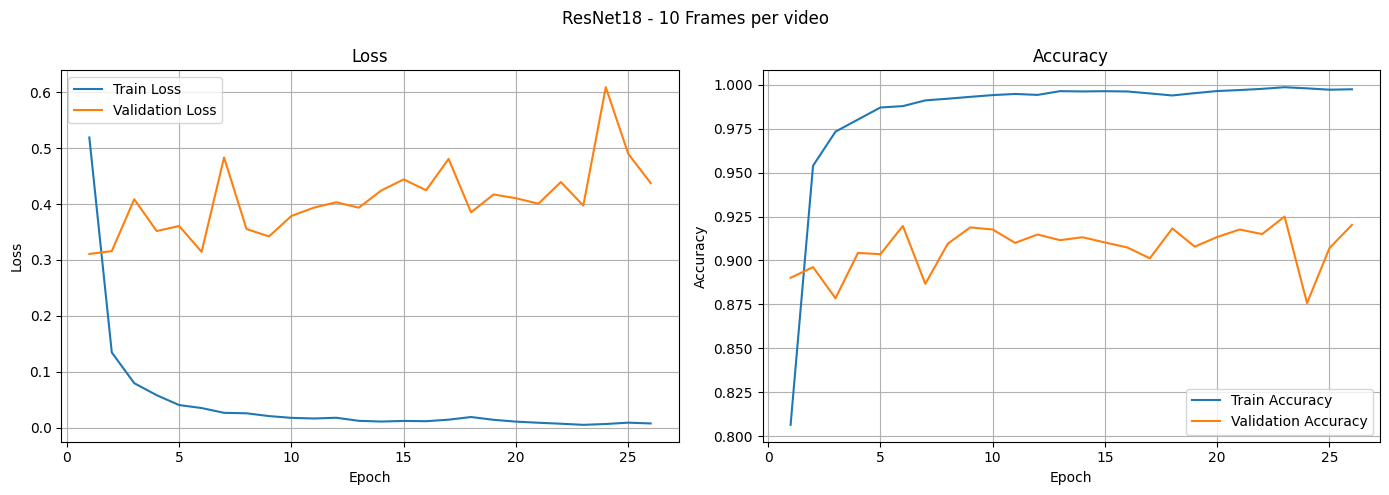

In [35]:
run_dir = "../outputs_hpc_ffpp/logs/ffpp__multiclass__resnet18__subset_None__frames_train_10__frames_val_10"
best_version = find_best_version(run_dir)
print(best_version)
log_dir = best_version["version_dir"]
plot_single_training_curves(log_dir, title="ResNet18 - 10 Frames per video")

{'version_dir': WindowsPath('../outputs_hpc_ffpp/logs/ffpp__multiclass__resnet18__subset_None__frames_train_1__frames_val_1/version_5'), 'best_val_acc': 0.8904761672019958, 'last_val_acc': 0.8904761672019958, 'n_epochs': 31, 'has_test': False}


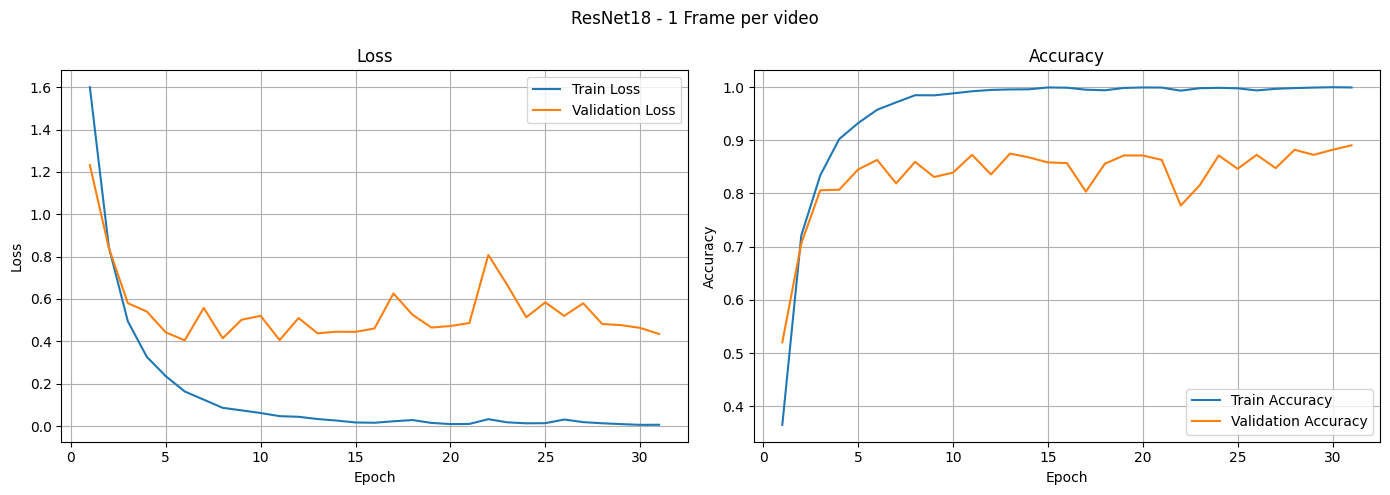

In [36]:
run_dir = "../outputs_hpc_ffpp/logs/ffpp__multiclass__resnet18__subset_None__frames_train_1__frames_val_1"
best_version = find_best_version(run_dir)
print(best_version)
log_dir = best_version["version_dir"]
plot_single_training_curves(log_dir, title="ResNet18 - 1 Frame per video")

{'version_dir': WindowsPath('../outputs_hpc_ffpp/logs/ffpp__multiclass__medium_cnn__subset_None__frames_train_100__frames_val_100/version_0'), 'best_val_acc': 0.923379123210907, 'last_val_acc': 0.9154020547866821, 'n_epochs': 34, 'has_test': False}


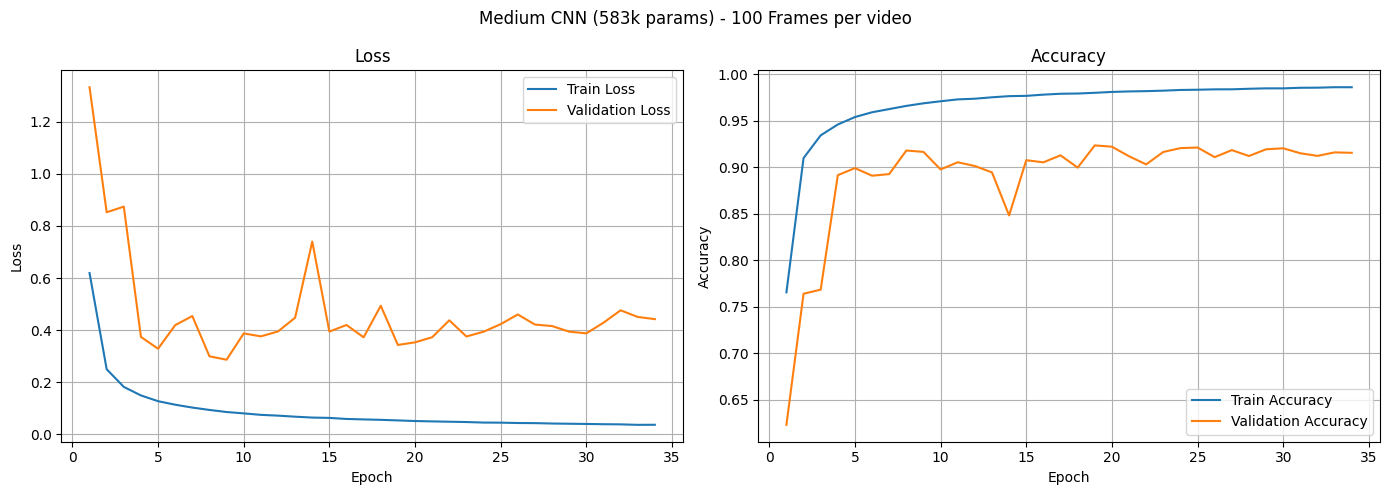

In [38]:
run_dir = "../outputs_hpc_ffpp/logs/ffpp__multiclass__medium_cnn__subset_None__frames_train_100__frames_val_100"
best_version = find_best_version(run_dir)
print(best_version)
log_dir = best_version["version_dir"]
plot_single_training_curves(log_dir, title="Medium CNN (583k params) - 100 Frames per video")

{'version_dir': WindowsPath('../outputs_hpc_ffpp/logs/ffpp__multiclass__medium_cnn__subset_None__frames_train_10__frames_val_10/version_0'), 'best_val_acc': 0.8946428298950195, 'last_val_acc': 0.885952353477478, 'n_epochs': 46, 'has_test': False}


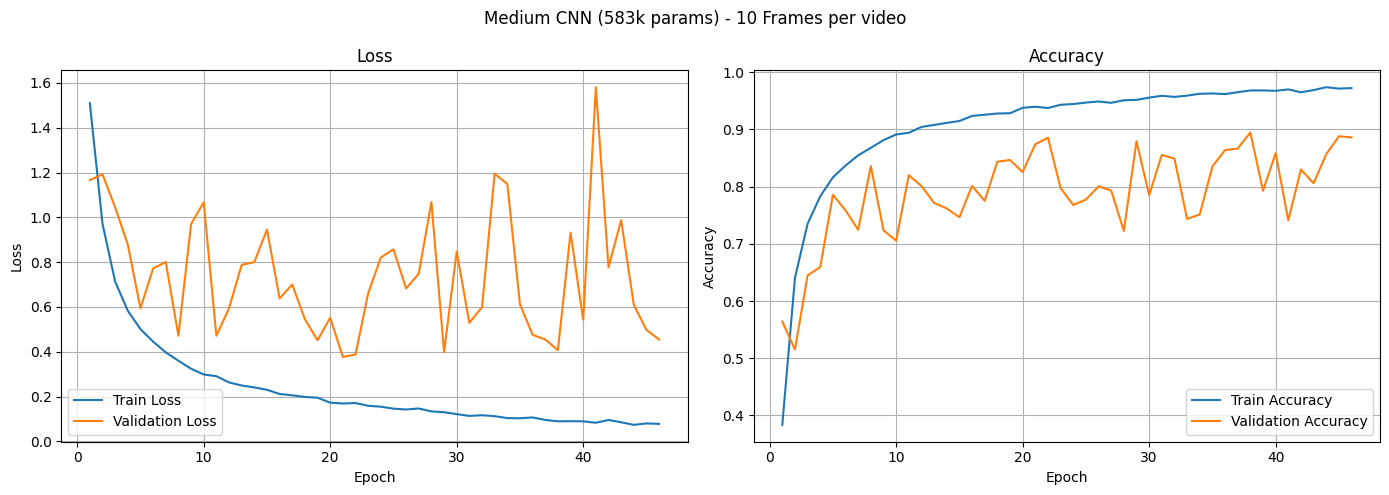

In [39]:
run_dir = "../outputs_hpc_ffpp/logs/ffpp__multiclass__medium_cnn__subset_None__frames_train_10__frames_val_10"
best_version = find_best_version(run_dir)
print(best_version)
log_dir = best_version["version_dir"]
plot_single_training_curves(log_dir, title="Medium CNN (583k params) - 10 Frames per video")

{'version_dir': WindowsPath('../outputs_hpc_ffpp/logs/ffpp__multiclass__medium_cnn__subset_None__frames_train_1__frames_val_1/version_0'), 'best_val_acc': 0.8214285969734192, 'last_val_acc': 0.6976190209388733, 'n_epochs': 77, 'has_test': False}


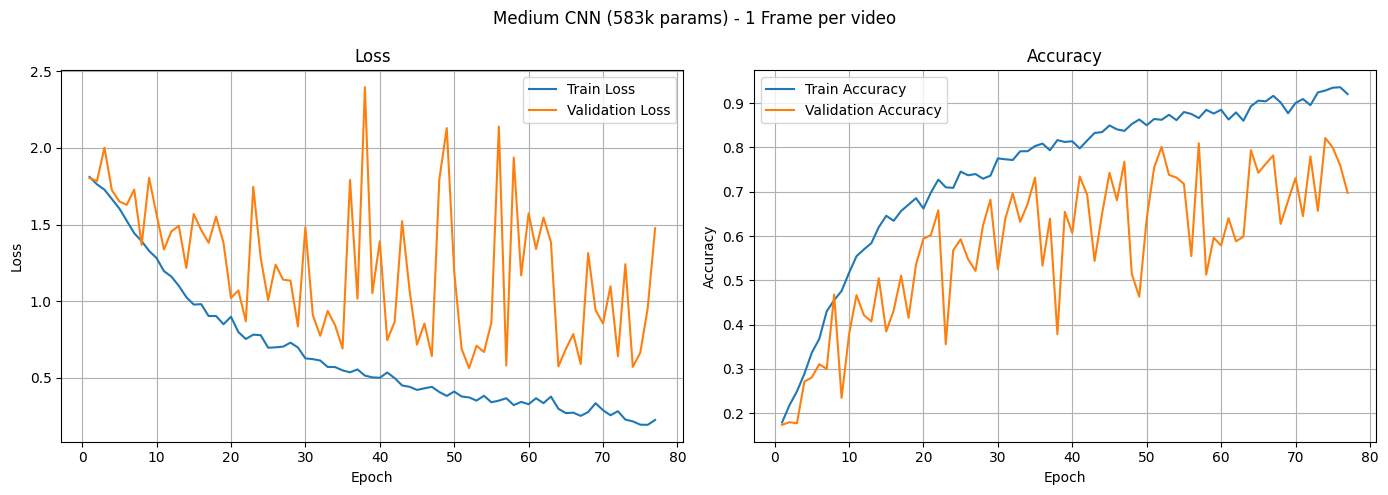

In [41]:
run_dir = "../outputs_hpc_ffpp/logs/ffpp__multiclass__medium_cnn__subset_None__frames_train_1__frames_val_1"
best_version = find_best_version(run_dir)
print(best_version)
log_dir = best_version["version_dir"]
plot_single_training_curves(log_dir, title="Medium CNN (583k params) - 1 Frame per video")

{'version_dir': WindowsPath('../outputs_hpc_ffpp/logs/ffpp__multiclass__small_cnn__subset_None__frames_train_100__frames_val_100/version_0'), 'best_val_acc': 0.8238450288772583, 'last_val_acc': 0.7927990555763245, 'n_epochs': 135, 'has_test': False}


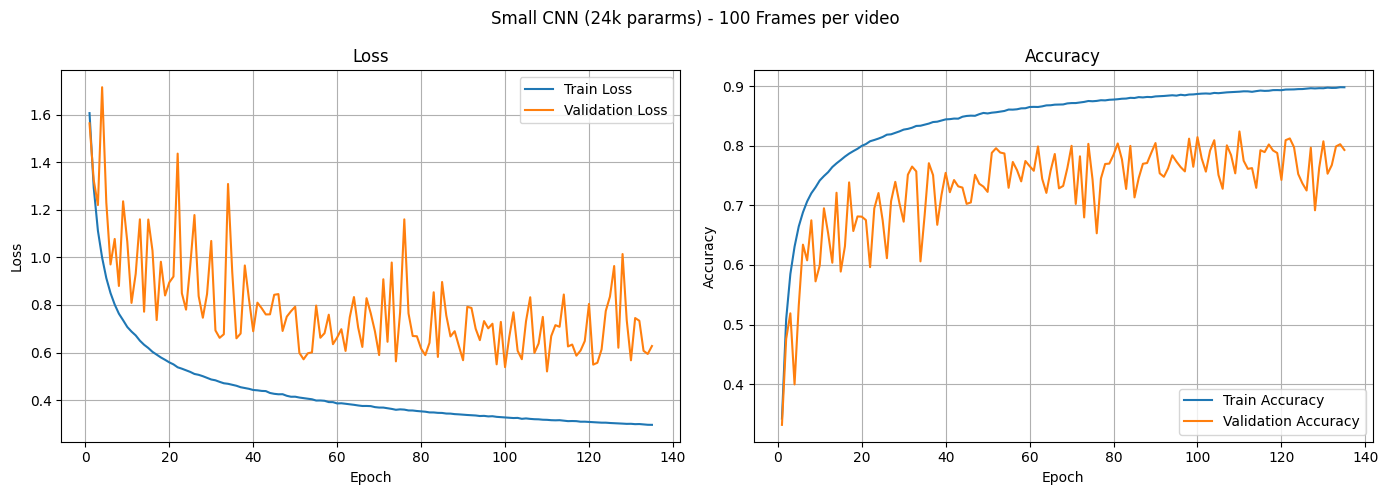

In [42]:
run_dir = "../outputs_hpc_ffpp/logs/ffpp__multiclass__small_cnn__subset_None__frames_train_100__frames_val_100"
best_version = find_best_version(run_dir)
print(best_version)
log_dir = best_version["version_dir"]
plot_single_training_curves(log_dir, title="Small CNN (24k pararms) - 100 Frames per video")

{'version_dir': WindowsPath('../outputs_hpc_ffpp/logs/ffpp__multiclass__small_cnn__subset_None__frames_train_10__frames_val_10/version_0'), 'best_val_acc': 0.7524999976158142, 'last_val_acc': 0.7038094997406006, 'n_epochs': 166, 'has_test': False}


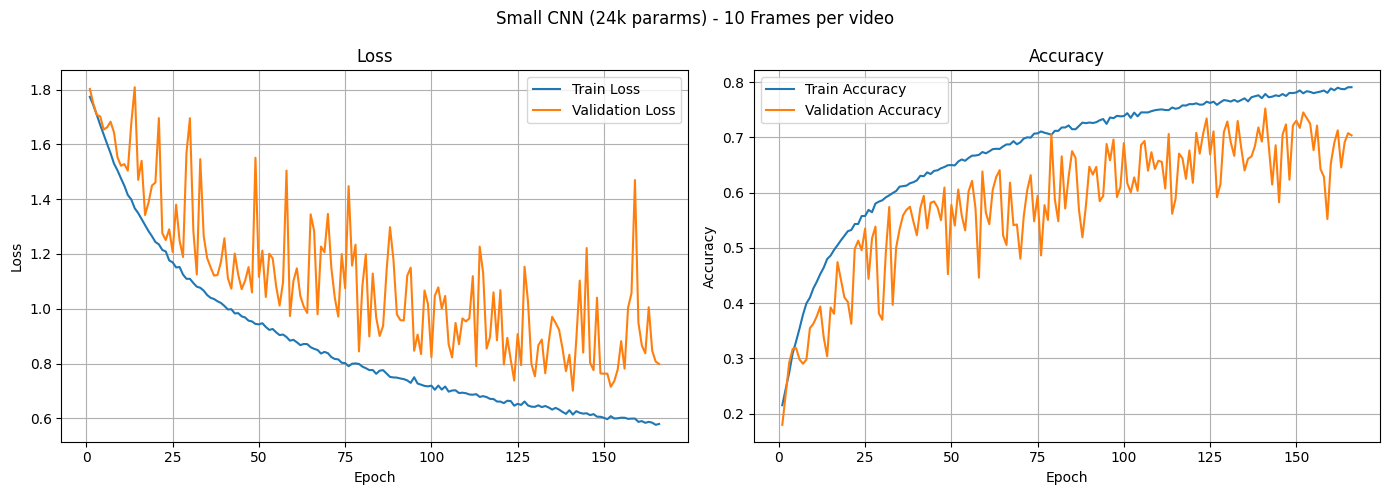

In [43]:
run_dir = "../outputs_hpc_ffpp/logs/ffpp__multiclass__small_cnn__subset_None__frames_train_10__frames_val_10"
best_version = find_best_version(run_dir)
print(best_version)
log_dir = best_version["version_dir"]
plot_single_training_curves(log_dir, title="Small CNN (24k pararms) - 10 Frames per video")

{'version_dir': WindowsPath('../outputs_hpc_ffpp/logs/ffpp__multiclass__small_cnn__subset_None__frames_train_1__frames_val_1/version_0'), 'best_val_acc': 0.4869047701358795, 'last_val_acc': 0.45476189255714417, 'n_epochs': 229, 'has_test': False}


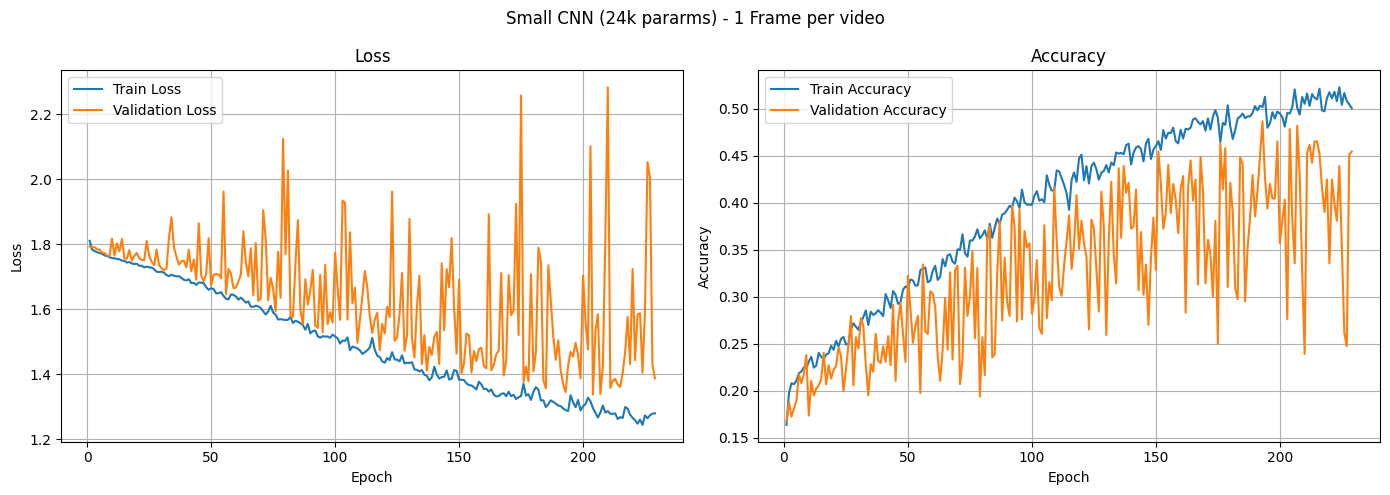

In [44]:
run_dir = "../outputs_hpc_ffpp/logs/ffpp__multiclass__small_cnn__subset_None__frames_train_1__frames_val_1"
best_version = find_best_version(run_dir)
print(best_version)
log_dir = best_version["version_dir"]
plot_single_training_curves(log_dir, title="Small CNN (24k pararms) - 1 Frame per video")

#### Plots for Binary

{'version_dir': WindowsPath('../outputs_hpc_ffpp/logs/ffpp__binary__resnet18__subset_None__frames_train_100__frames_val_100/version_0'), 'best_val_acc': 0.9467235207557678, 'last_val_acc': 0.9373929500579834, 'n_epochs': 26, 'has_test': False}


KeyError: 'train_loss_epoch'

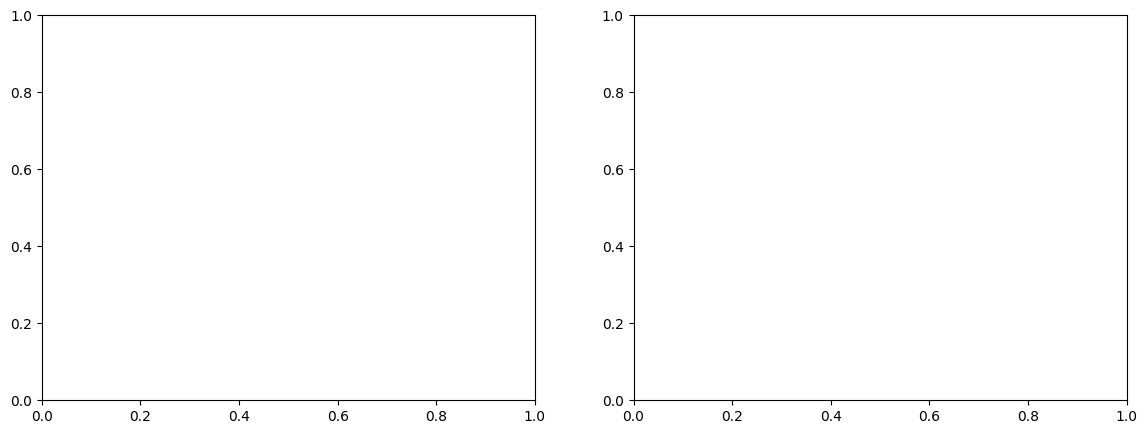

In [22]:
run_dir = "../outputs_hpc_ffpp/logs/ffpp__binary__resnet18__subset_None__frames_train_100__frames_val_100"
best_version = find_best_version(run_dir)
print(best_version)
log_dir = best_version["version_dir"]
plot_single_training_curves(log_dir, title="ResNet18 - 100 Frames per video")

### Test set performance

In [47]:
trainer.test(best_model, datamodule=data_module)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Class mapping: {'Original': 0, 'Deepfakes': 1, 'Face2Face': 2, 'FaceShifter': 3, 'FaceSwap': 4, 'NeuralTextures': 5}
Train: 4308
Validation: 832
Test: 83113

Train counts:
Original: 717
Deepfakes: 717
Face2Face: 719
FaceShifter: 720
FaceSwap: 719
NeuralTextures: 716

Validation counts:
Original: 139
Deepfakes: 138
Face2Face: 139
FaceShifter: 139
FaceSwap: 138
NeuralTextures: 139

Test counts:
Original: 13864
Deepfakes: 13763
Face2Face: 13908
FaceShifter: 13822
FaceSwap: 13851
NeuralTextures: 13905


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9102908372879028     │
│         test_loss         │    0.3206372559070587     │
│       test_macro_f1       │    0.9109866619110107     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.3206372559070587,
  'test_acc': 0.9102908372879028,
  'test_macro_f1': 0.9109866619110107}]

In [50]:
def get_dataset_paths(dataset):

    frame_paths = []

    if isinstance(dataset, Subset):

        base_dataset = dataset.dataset
        dataset_indices = dataset.indices

    else:

        base_dataset = dataset
        dataset_indices = range(len(base_dataset))

    for index in dataset_indices:

        frame_path, _ = base_dataset.samples[index]

        frame_paths.append(
            frame_path
        )

    return np.array(
        frame_paths,
        dtype=object
    )

In [51]:
def get_multiclass_predictions(model, data_module, device=None):

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    dataloader = data_module.test_dataloader()

    model.eval()
    model.to(device)

    y_true_batches = []
    y_pred_batches = []
    y_prob_batches = []

    with torch.inference_mode():

        for images, labels in dataloader:

            images = images.to(device)

            logits = model(images)

            probabilities = torch.softmax(logits, dim=1)
            predictions = torch.argmax(probabilities, dim=1)

            y_true_batches.append(
                labels.cpu()
            )

            y_pred_batches.append(
                predictions.cpu()
            )

            y_prob_batches.append(
                probabilities.cpu()
            )

    y_true = torch.cat(
        y_true_batches,
        dim=0
    ).numpy()

    y_pred = torch.cat(
        y_pred_batches,
        dim=0
    ).numpy()

    y_prob = torch.cat(
        y_prob_batches,
        dim=0
    ).numpy()

    frame_paths = get_dataset_paths(
        data_module.test_dataset
    )

    if len(frame_paths) != len(y_true):

        raise RuntimeError(
            f"Found {len(frame_paths)} paths but {len(y_true)} predictions."
        )

    return frame_paths, y_true, y_pred, y_prob

In [48]:
def get_multiclass_predictions(model, data_module, device=None):

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    dataloader = data_module.test_dataloader()

    model.eval()
    model.to(device)

    X = []
    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)

            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            X.append(images.cpu())
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())
    X = torch.cat(X, dim=0).numpy()

    return np.array(X), np.array(y_true), np.array(y_pred), np.array(y_prob)

In [52]:
X_test_paths, y_true, y_pred, y_prob = get_multiclass_predictions(
    best_model,
    data_module
)

In [53]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

                precision    recall  f1-score   support

      Original     0.8211    0.7903    0.8054     13864
     Deepfakes     0.9436    0.9417    0.9426     13763
     Face2Face     0.9429    0.9467    0.9448     13908
   FaceShifter     0.9759    0.9328    0.9539     13822
      FaceSwap     0.9881    0.9240    0.9550     13851
NeuralTextures     0.8096    0.9261    0.8639     13905

      accuracy                         0.9102     83113
     macro avg     0.9135    0.9103    0.9109     83113
  weighted avg     0.9134    0.9102    0.9109     83113



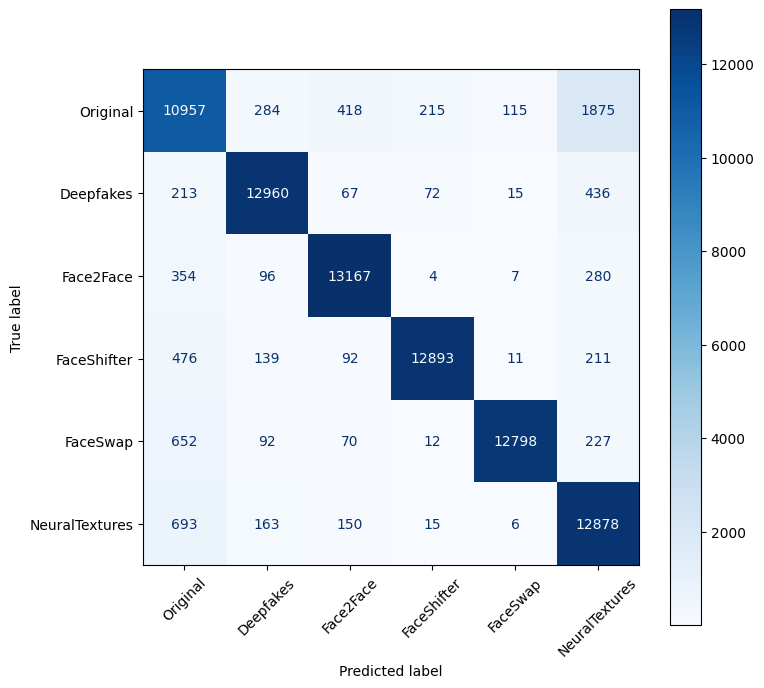

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
    plt.show()
plot_confusion_matrix(y_true, y_pred, CLASSES)

In [58]:
# Build frame-level predictions and aggregate them into video-level predictions
def build_frame_and_video_predictions(data_module, y_true, y_pred, y_prob, class_names):

    dataset = data_module.test_dataset

    rows = []

    # get samples from a Subset or from a normal ImageFolder
    if isinstance(dataset, Subset):
        base_dataset = dataset.dataset
        sample_indices = dataset.indices

        for dataset_index, base_index in enumerate(sample_indices):

            frame_path, label = base_dataset.samples[base_index]

            class_name = class_names[label]
            video_key = extract_video_key_from_frame_path(frame_path, class_name)
            rows.append({"dataset_index": dataset_index, "frame_path": frame_path, "video_key": video_key, "true_class": class_name, "y_true": label})

    else:
        for dataset_index, sample in enumerate(dataset.samples):

            frame_path, label = sample

            class_name = class_names[label]
            video_key = extract_video_key_from_frame_path(frame_path, class_name)
            rows.append({"dataset_index": dataset_index, "frame_path": frame_path, "video_key": video_key, "true_class": class_name, "y_true": label})

    frame_df = pd.DataFrame(rows)

    # check that metadata and predictions have the same length
    if len(frame_df) != len(y_true):
        raise ValueError(f"Metadata length ({len(frame_df)}) and prediction length ({len(y_true)}) do not match.")

    # add frame-level predictions
    frame_df["y_true"] = y_true
    frame_df["y_pred"] = y_pred
    frame_df["pred_class"] = [class_names[label] for label in y_pred]

    # add one probability column for each class
    prob_columns = []

    for class_index, class_name in enumerate(class_names):
        prob_column = "prob_" + class_name
        frame_df[prob_column] = y_prob[:, class_index]
        prob_columns.append(prob_column)

    # aggregate frame probabilities into video probabilities
    video_rows = []

    grouped = frame_df.groupby(["true_class", "video_key"])

    for (true_class, video_key), group in grouped:
        mean_probs = group[prob_columns].mean().values # average predictions per frame

        y_true_video = group["y_true"].iloc[0]
        y_pred_video = np.argmax(mean_probs)

        row = {"true_class": true_class, "video_key": video_key, "n_frames": len(group), "y_true": y_true_video, "y_pred": y_pred_video, "pred_class": class_names[y_pred_video]}

        for class_index, class_name in enumerate(class_names):
            prob_column = "prob_" + class_name
            row[prob_column] = mean_probs[class_index]

        video_rows.append(row)

    video_df = pd.DataFrame(video_rows)

    return frame_df, video_df

In [59]:
def get_video_prediction_arrays(video_predictions_df, class_names):

    # get true labels and predicted labels at video level
    y_true_video = video_predictions_df["y_true"].values
    y_pred_video = video_predictions_df["y_pred"].values

    # get video-level probability columns
    prob_columns = []

    for class_name in class_names:
        prob_columns.append("prob_" + class_name)

    # get video-level probability matrix
    y_prob_video = video_predictions_df[prob_columns].values

    return y_true_video, y_pred_video, y_prob_video

In [60]:
frame_predictions_df, video_predictions_df = build_frame_and_video_predictions(data_module, y_true, y_pred, y_prob, CLASSES)
y_true_video, y_pred_video, y_prob_video = get_video_prediction_arrays(video_predictions_df, CLASSES)

In [119]:
#display(frame_predictions_df.head())
#display(video_predictions_df.head())

,dataset_index,frame_path,video_key,true_class,y_true,y_pred,pred_class,prob_Original,prob_Deepfakes,prob_Face2Face,prob_FaceShifter,prob_FaceSwap,prob_NeuralTextures
0,0,c:\Users\tomma\DeepfakeSII\datasets\fff++_6cla...,000_003,Deepfakes,1,1,Deepfakes,0.000033,0.999885,0.000070,0.000006,0.000001,0.000006
1,1,c:\Users\tomma\DeepfakeSII\datasets\fff++_6cla...,000_003,Deepfakes,1,1,Deepfakes,0.000105,0.999528,0.000197,0.000029,0.000015,0.000126
2,2,c:\Users\tomma\DeepfakeSII\datasets\fff++_6cla...,000_003,Deepfakes,1,1,Deepfakes,0.000401,0.999345,0.000204,0.000010,0.000014,0.000026
3,3,c:\Users\tomma\DeepfakeSII\datasets\fff++_6cla...,000_003,Deepfakes,1,1,Deepfakes,0.000791,0.997743,0.001152,0.000060,0.000018,0.000236
4,4,c:\Users\tomma\DeepfakeSII\datasets\fff++_6cla...,000_003,Deepfakes,1,1,Deepfakes,0.000189,0.998966,0.000061,0.000016,0.000007,0.000760


,true_class,video_key,n_frames,y_true,y_pred,pred_class,prob_Original,prob_Deepfakes,prob_Face2Face,prob_FaceShifter,prob_FaceSwap,prob_NeuralTextures
0,Deepfakes,000_003,10,1,1,Deepfakes,0.004377,0.988777,0.006237,0.000152,0.000060,0.000397
1,Deepfakes,003_000,10,1,1,Deepfakes,0.191403,0.641613,0.000365,0.161397,0.002748,0.002475
2,Deepfakes,012_026,10,1,5,NeuralTextures,0.204683,0.134371,0.005097,0.241685,0.005578,0.408587
3,Deepfakes,015_919,10,1,0,Original,0.547660,0.153392,0.012868,0.190780,0.002296,0.093004
4,Deepfakes,024_073,10,1,1,Deepfakes,0.012826,0.966388,0.006354,0.013578,0.000600,0.000255


In [61]:
print(classification_report(y_true_video, y_pred_video, target_names=CLASSES, digits=4))

                precision    recall  f1-score   support

      Original     0.9091    0.8571    0.8824       140
     Deepfakes     0.9854    0.9643    0.9747       140
     Face2Face     0.9648    0.9786    0.9716       140
   FaceShifter     0.9856    0.9786    0.9821       140
      FaceSwap     1.0000    0.9857    0.9928       140
NeuralTextures     0.8684    0.9429    0.9041       140

      accuracy                         0.9512       840
     macro avg     0.9522    0.9512    0.9513       840
  weighted avg     0.9522    0.9512    0.9513       840



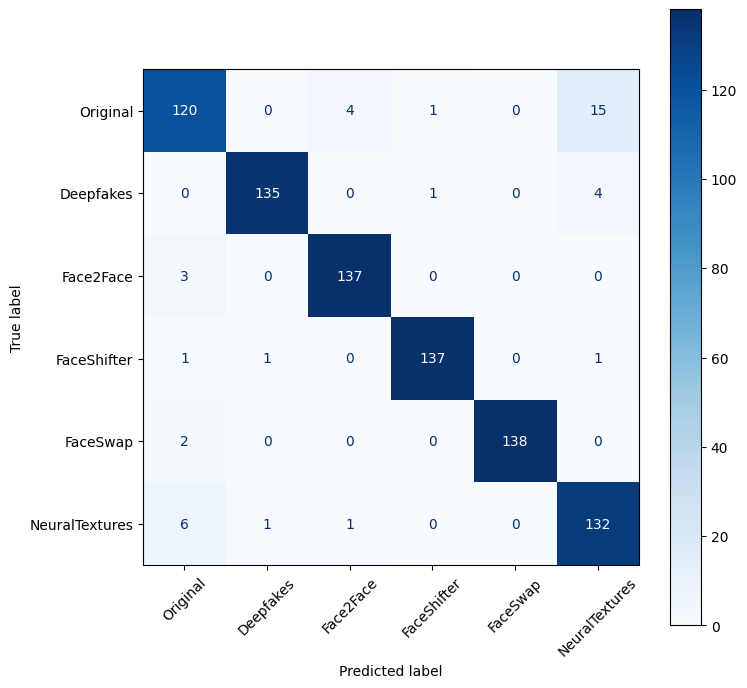

In [62]:
plot_confusion_matrix(y_true_video, y_pred_video, CLASSES)

In [63]:
# Deepfakes_000_003_sample_004_frame_000123.png -> 004
def extract_frame_number_from_path(frame_path):
    stem = Path(frame_path).stem
    frame_number = int(stem.split("_frame_")[-1])
    return frame_number

In [64]:
# helper
def unnormalize_image(image):

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image.transpose(1, 2, 0)
    image = (image * std) + mean

    return np.clip(image, 0, 1)

In [155]:
def show_video_predictions_grid(X, frame_predictions_df, video_predictions_df, class_names, seed=42, true_class=None, video_key=None, n_cols=5):

    # Show all test frames of one video with frame-level predictions and final video-level prediction

    rng = np.random.default_rng(seed)

    # Select a specific video if true_class and video_key are given
    if true_class is not None and video_key is not None:

        selected_video_df = video_predictions_df[
            (video_predictions_df["true_class"] == true_class) &
            (video_predictions_df["video_key"] == video_key)
        ]

        if len(selected_video_df) == 0:
            print("Video not found.")
            return

        video_row = selected_video_df.iloc[0]

    # Otherwise select a random video
    else:

        random_index = rng.integers(0, len(video_predictions_df))

        video_row = video_predictions_df.iloc[random_index]

        true_class = video_row["true_class"]
        video_key = video_row["video_key"]

    # Select all frames belonging to the selected video
    video_frames_df = frame_predictions_df[
        (frame_predictions_df["true_class"] == true_class) &
        (frame_predictions_df["video_key"] == video_key)
    ].copy()

    # Sort frames by original frame number
    video_frames_df["frame_number"] = video_frames_df["frame_path"].apply(extract_frame_number_from_path)
    video_frames_df = video_frames_df.sort_values("frame_number")

    # Get final video-level prediction
    video_true_class = video_row["true_class"]
    video_pred_class = video_row["pred_class"]
    video_confidence = video_row["prob_" + video_pred_class]

    # Create grid
    n_frames = len(video_frames_df)
    n_rows = int(np.ceil(n_frames / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 4 * n_rows))

    axes = np.array(axes).reshape(-1)

    for i, ax in enumerate(axes):

        if i >= n_frames:

            ax.axis("off")
            continue

        row = video_frames_df.iloc[i]

        dataset_index = int(row["dataset_index"])

        image = unnormalize_image(X[dataset_index])

        frame_true_class = row["true_class"]
        frame_pred_class = row["pred_class"]
        frame_confidence = row["prob_" + frame_pred_class]
        frame_number = row["frame_number"]

        ax.imshow(image)

        ax.set_title(
            f"Frame {frame_number}\n"
            f"T: {frame_true_class}\n"
            f"P: {frame_pred_class}\n"
            f"Conf: {frame_confidence:.2f}",
            fontsize=9,
            color=("green" if frame_true_class == frame_pred_class else "red")
        )

        ax.axis("off")

    plt.suptitle(
        f"Video: {video_true_class}_{video_key}\n"
        f"Final video prediction: {video_pred_class} | Confidence: {video_confidence:.2f}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

    return video_row, video_frames_df

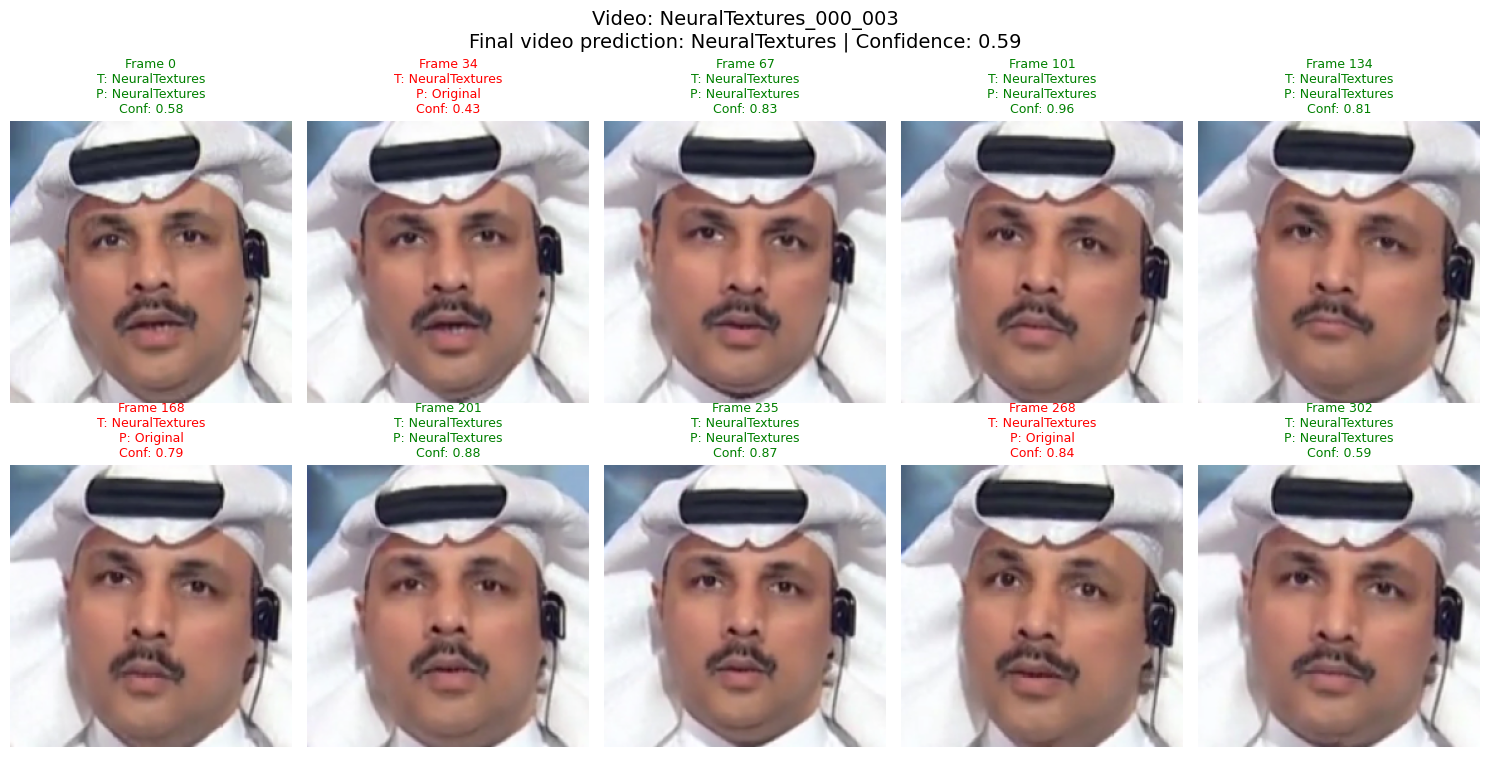

In [ ]:
video_row, video_frames_df = show_video_predictions_grid(
    X_test,
    frame_predictions_df,
    video_predictions_df,
    CLASSES,
    seed=28,
    # true_class="Deepfakes",
    # video_key="000_003"
)

In [65]:
def analyze_confidence(y_true, y_pred, y_prob, title="Prediction Confidence"):

    # compute confidence as the probability assigned to the predicted class
    confidences = y_prob[np.arange(len(y_pred)), y_pred]

    # split confidence values into correct and wrong predictions
    correct_conf = confidences[y_true == y_pred]
    wrong_conf = confidences[y_true != y_pred]

    # print basic stats
    print(title)
    print()

    print(f"Correct predictions: {len(correct_conf)}")
    print(f"Wrong predictions: {len(wrong_conf)}")
    print()

    print(f"Mean confidence (correct): {correct_conf.mean():.4f}")

    if len(wrong_conf) > 0:
        print(f"Mean confidence (wrong):   {wrong_conf.mean():.4f}")
    else:
        print("Mean confidence (wrong):   no wrong predictions")

    # plot confidence distributions
    plt.figure(figsize=(8, 5))
    plt.hist(correct_conf, bins=30, alpha=0.6, density=True, label="Correct")

    if len(wrong_conf) > 0:
        plt.hist(wrong_conf, bins=30, alpha=0.6, density=True, label="Wrong")

    plt.xlabel("Confidence")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

Frame-Level Prediction Confidence

Correct predictions: 75653
Wrong predictions: 7460

Mean confidence (correct): 0.9735
Mean confidence (wrong):   0.7147


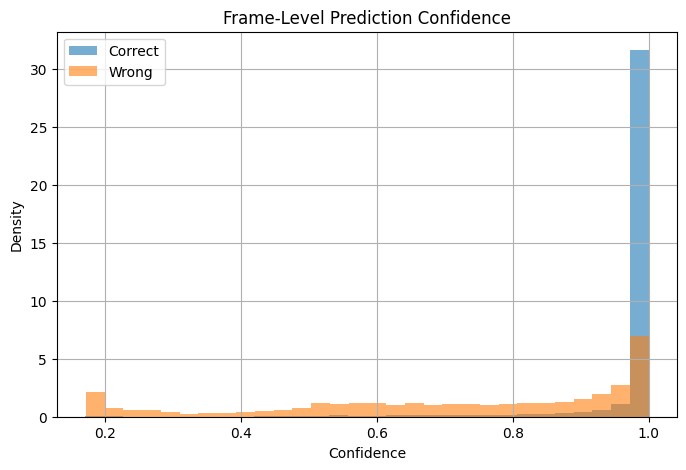

In [66]:
analyze_confidence(y_true, y_pred, y_prob, title="Frame-Level Prediction Confidence")

Video-Level Prediction Confidence

Correct predictions: 799
Wrong predictions: 41

Mean confidence (correct): 0.9305
Mean confidence (wrong):   0.6257


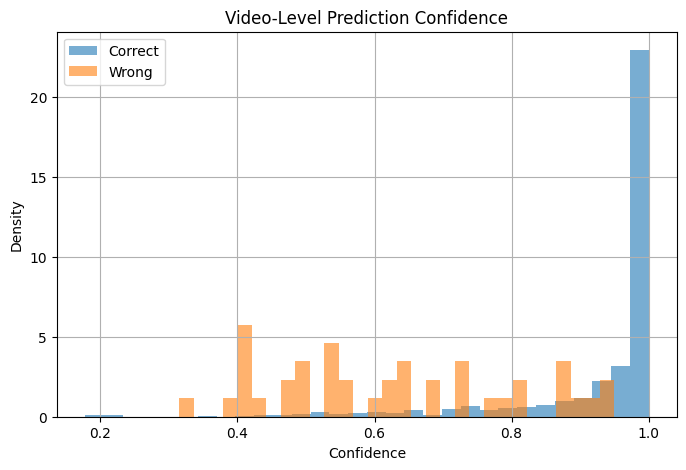

In [67]:
analyze_confidence(y_true_video, y_pred_video, y_prob_video, title="Video-Level Prediction Confidence")

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


def plot_frame_correctness_distribution_by_video(
    frame_predictions_df,
    video_predictions_df,
    use_rate=True,
    rate_bin_width=0.05,
    frame_bin_width=10,
    normalize=True
):

    # Copy frame-level dataframe
    frame_df = frame_predictions_df.copy()

    # Mark each frame as correct or wrong
    frame_df["frame_correct"] = frame_df["y_true"] == frame_df["y_pred"]

    # Calculate frame-level statistics for each video
    frame_stats_df = (
        frame_df
        .groupby(["true_class", "video_key"])
        .agg(
            n_video_frames=("frame_correct", "count"),
            n_correct_frames=("frame_correct", "sum"),
            frame_correct_rate=("frame_correct", "mean")
        )
        .reset_index()
    )

    # Copy video-level dataframe
    video_df = video_predictions_df.copy()

    # Mark each video as correct or wrong
    video_df["video_correct"] = video_df["y_true"] == video_df["y_pred"]

    # Avoid duplicate n_frames column after merge
    if "n_frames" in video_df.columns:
        video_df = video_df.drop(columns=["n_frames"])

    # Merge frame-level and video-level information
    analysis_df = video_df.merge(
        frame_stats_df,
        on=["true_class", "video_key"],
        how="left"
    )

    # Split correct and wrong video predictions
    correct_videos = analysis_df[analysis_df["video_correct"] == True]
    wrong_videos = analysis_df[analysis_df["video_correct"] == False]

    # Print summary statistics
    print("Frame correctness per video")
    print()

    print(f"Correct videos: {len(correct_videos)}")
    print(f"Wrong videos:   {len(wrong_videos)}")
    print()

    print(f"Mean correct frames in correct videos:   {correct_videos['n_correct_frames'].mean():.2f}")
    print(f"Median correct frames in correct videos: {correct_videos['n_correct_frames'].median():.2f}")
    print()

    print(f"Mean correct frames in wrong videos:     {wrong_videos['n_correct_frames'].mean():.2f}")
    print(f"Median correct frames in wrong videos:   {wrong_videos['n_correct_frames'].median():.2f}")
    print()

    print(f"Mean correct frame rate in correct videos:   {correct_videos['frame_correct_rate'].mean():.4f}")
    print(f"Median correct frame rate in correct videos: {correct_videos['frame_correct_rate'].median():.4f}")
    print()

    print(f"Mean correct frame rate in wrong videos:     {wrong_videos['frame_correct_rate'].mean():.4f}")
    print(f"Median correct frame rate in wrong videos:   {wrong_videos['frame_correct_rate'].median():.4f}")

    # Create plots
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5),
        sharey=normalize
    )

    if use_rate:

        # Check that the bin width is valid
        if rate_bin_width <= 0 or rate_bin_width > 1:
            raise ValueError("rate_bin_width must be between 0 and 1.")

        # Create equally spaced bins between 0 and 1
        n_bins = int(round(1 / rate_bin_width))
        bin_edges = np.linspace(0, 1, n_bins + 1)

        # Extract frame correctness rates
        correct_values = correct_videos["frame_correct_rate"].dropna().to_numpy()
        wrong_values = wrong_videos["frame_correct_rate"].dropna().to_numpy()

        # Count videos inside each interval
        correct_counts, _ = np.histogram(correct_values, bins=bin_edges)
        wrong_counts, _ = np.histogram(wrong_values, bins=bin_edges)

        # Normalize each group independently
        if normalize:

            if correct_counts.sum() > 0:
                correct_counts = correct_counts / correct_counts.sum() * 100

            if wrong_counts.sum() > 0:
                wrong_counts = wrong_counts / wrong_counts.sum() * 100

        # Calculate bar positions
        x_values = (bin_edges[:-1] + bin_edges[1:]) / 2
        bar_width = rate_bin_width * 0.9

        axes[0].bar(
            x_values,
            correct_counts,
            width=bar_width
        )

        axes[1].bar(
            x_values,
            wrong_counts,
            width=bar_width
        )

        axes[0].set_xlim(0, 1)
        axes[1].set_xlim(0, 1)

        axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

        axes[0].set_xticks(np.arange(0, 1.01, 0.1))
        axes[1].set_xticks(np.arange(0, 1.01, 0.1))

        x_label = "Correctly classified frames"

    else:

        # Check that the bin width is valid
        if frame_bin_width < 1:
            raise ValueError("frame_bin_width must be at least 1.")

        # Find the maximum number of available frames
        max_frames = int(analysis_df["n_video_frames"].max())

        # Create grouped frame-count bins
        max_edge = int(np.ceil(max_frames / frame_bin_width) * frame_bin_width)
        bin_edges = np.arange(0, max_edge + frame_bin_width, frame_bin_width)

        # Extract numbers of correctly classified frames
        correct_values = correct_videos["n_correct_frames"].dropna().to_numpy()
        wrong_values = wrong_videos["n_correct_frames"].dropna().to_numpy()

        # Count videos inside each interval
        correct_counts, _ = np.histogram(correct_values, bins=bin_edges)
        wrong_counts, _ = np.histogram(wrong_values, bins=bin_edges)

        # Normalize each group independently
        if normalize:

            if correct_counts.sum() > 0:
                correct_counts = correct_counts / correct_counts.sum() * 100

            if wrong_counts.sum() > 0:
                wrong_counts = wrong_counts / wrong_counts.sum() * 100

        # Calculate bar positions
        x_values = (bin_edges[:-1] + bin_edges[1:]) / 2
        bar_width = frame_bin_width * 0.9

        axes[0].bar(
            x_values,
            correct_counts,
            width=bar_width
        )

        axes[1].bar(
            x_values,
            wrong_counts,
            width=bar_width
        )

        x_label = "Number of correctly classified frames"

    # Set titles and labels
    axes[0].set_title("Correct Video Predictions")
    axes[0].set_xlabel(x_label)
    axes[0].grid(axis="y", alpha=0.3)

    axes[1].set_title("Wrong Video Predictions")
    axes[1].set_xlabel(x_label)
    axes[1].grid(axis="y", alpha=0.3)

    if normalize:
        axes[0].set_ylabel("Percentage of videos")
        axes[1].set_ylabel("Percentage of videos")

    else:
        axes[0].set_ylabel("Number of videos")
        axes[1].set_ylabel("Number of videos")

    plt.suptitle(
        "Frame Correctness Distribution by Video-Level Outcome"
    )

    plt.tight_layout()
    plt.show()

    return analysis_df

Frame correctness per video

Correct videos: 799
Wrong videos:   41

Mean correct frames in correct videos:   93.51
Median correct frames in correct videos: 100.00

Mean correct frames in wrong videos:     22.80
Median correct frames in wrong videos:   18.00

Mean correct frame rate in correct videos:   0.9438
Median correct frame rate in correct videos: 1.0000

Mean correct frame rate in wrong videos:     0.2327
Median correct frame rate in wrong videos:   0.1800


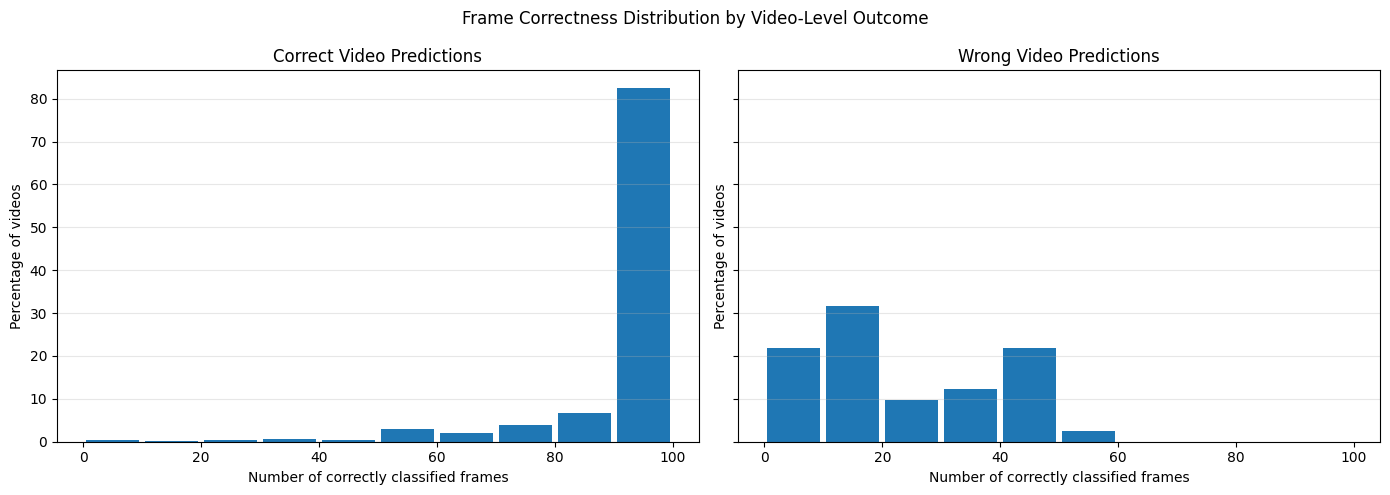

In [75]:
video_frame_correctness_df = plot_frame_correctness_distribution_by_video(
    frame_predictions_df,
    video_predictions_df,
    use_rate=False
)

Frame correctness per video

Correct videos: 780
Wrong videos:   59

Mean correct frames in correct videos: 9.22
Mean correct frames in wrong videos:   2.12

Mean correct frame rate in correct videos: 0.9318
Mean correct frame rate in wrong videos:   0.2119


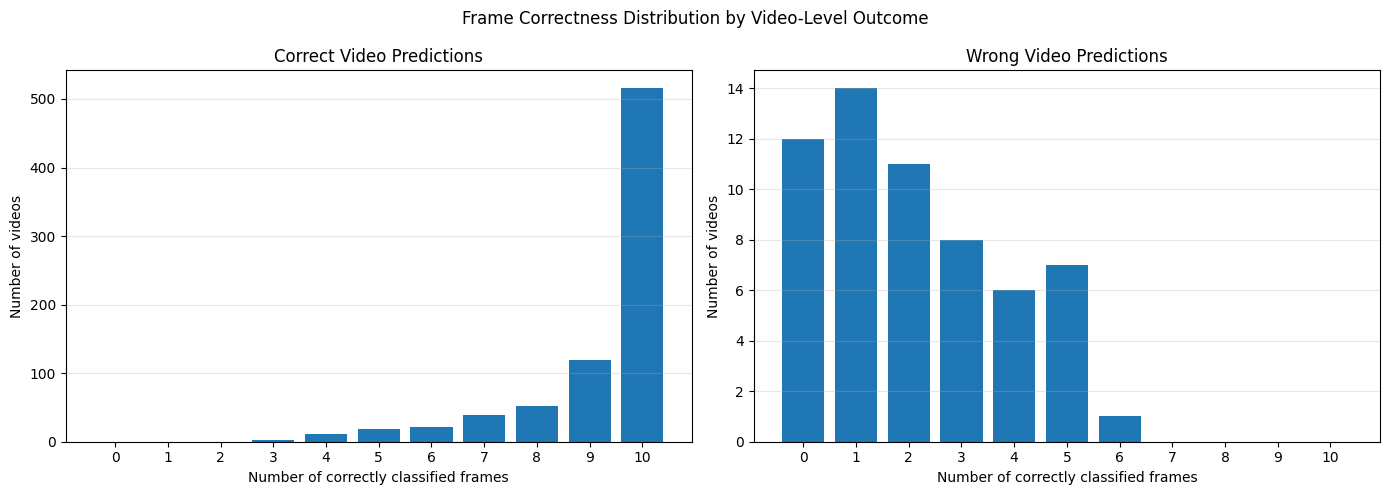

In [206]:
video_frame_correctness_df = plot_frame_correctness_distribution_by_video(
    frame_predictions_df,
    video_predictions_df,
    use_rate=False
)

## Explainability

In [72]:
def compute_gradcam_multiclass(model, image_tensor, target_class, alpha=0.5, device=None):

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model.eval()
    model.to(device)

    image_tensor = image_tensor.to(device)

    target_layers = [model.model.layer4[-1]] # last convolutional layer of ResNet18

    cam = GradCAM(model=model, target_layers=target_layers) # create Grad-CAM object

    target = [ClassifierOutputTarget(int(target_class))] # model prediction, the output to explain

    grayscale_cam = cam(input_tensor=image_tensor.unsqueeze(0), targets=target)[0] # calculate Grad-CAM heatmap (224,224) 

    image = unnormalize_image(image_tensor.detach().cpu().numpy()) # unnormalize for visualization

    overlay = show_cam_on_image(image, grayscale_cam, use_rgb=True, image_weight=alpha) # overlay heatmap on image

    return image, overlay

In [73]:
# Show Grad-CAM overlays for all test frames of one video
def show_video_gradcams(model, X, frame_predictions_df, video_predictions_df, class_names, true_class=None, video_key=None, seed=42, n_cols=5):

    rng = np.random.default_rng(seed)

    # select a specific video if true_class and video_key are provided
    if true_class is not None and video_key is not None:

        selected_video_df = video_predictions_df[(video_predictions_df["true_class"] == true_class) & (video_predictions_df["video_key"] == video_key)]

        if len(selected_video_df) == 0:
            print("Video not found.")
            return

        video_row = selected_video_df.iloc[0]

    # else select a random video
    else:
        random_index = rng.integers(0, len(video_predictions_df))

        video_row = video_predictions_df.iloc[random_index]

        true_class = video_row["true_class"]
        video_key = video_row["video_key"]

    # select all frames belonging to the selected video
    video_frames_df = frame_predictions_df[(frame_predictions_df["true_class"] == true_class) & (frame_predictions_df["video_key"] == video_key)].copy()

    # sort frames by original frame number
    video_frames_df["frame_number"] = video_frames_df["frame_path"].apply(extract_frame_number_from_path)
    video_frames_df = video_frames_df.sort_values("frame_number")

    # get video-level prediction
    video_true_class = video_row["true_class"]
    video_pred_class = video_row["pred_class"]
    video_confidence = video_row["prob_" + video_pred_class]

    # plot
    n_frames = len(video_frames_df)
    n_rows = int(np.ceil(n_frames / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 4 * n_rows))

    axes = np.array(axes).reshape(-1)

    for i, ax in enumerate(axes):

        if i >= n_frames:
            ax.axis("off")
            continue

        row = video_frames_df.iloc[i]
        dataset_index = int(row["dataset_index"])
        image_tensor = torch.tensor(X[dataset_index], dtype=torch.float32)

        frame_true_class = row["true_class"]
        frame_pred_class = row["pred_class"]
        frame_confidence = row["prob_" + frame_pred_class]
        frame_number = row["frame_number"]

        _, overlay = compute_gradcam_multiclass(model, image_tensor, row["y_pred"])
        ax.imshow(overlay)

        ax.set_title(
            f"Frame {frame_number}\n"
            f"T: {frame_true_class}\n"
            f"P: {frame_pred_class}\n"
            f"Conf: {frame_confidence:.2f}",
            fontsize=8,
            color=("green" if frame_true_class == frame_pred_class else "red")
        )

        ax.axis("off")

    plt.suptitle(
        f"Video: {video_true_class}_{video_key}\n"
        f"Final video prediction: {video_pred_class} | Confidence: {video_confidence:.2f}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

    return video_row, video_frames_df

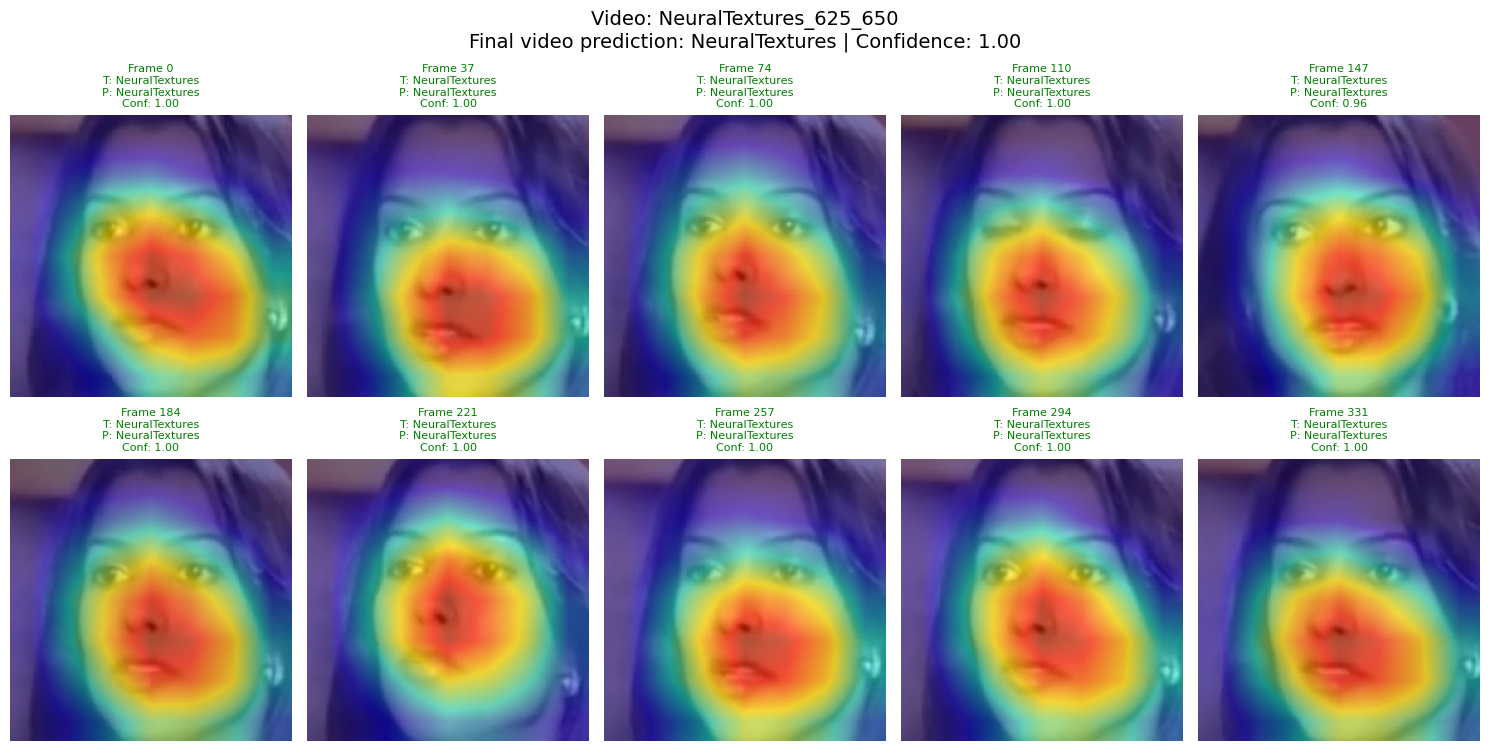

In [245]:
video_row, video_frames_df = show_video_gradcams(
    best_model,
    X_test,
    frame_predictions_df,
    video_predictions_df,
    CLASSES,
    seed=22,
    # true_class="Deepfakes",
    # video_key="000_003"
)

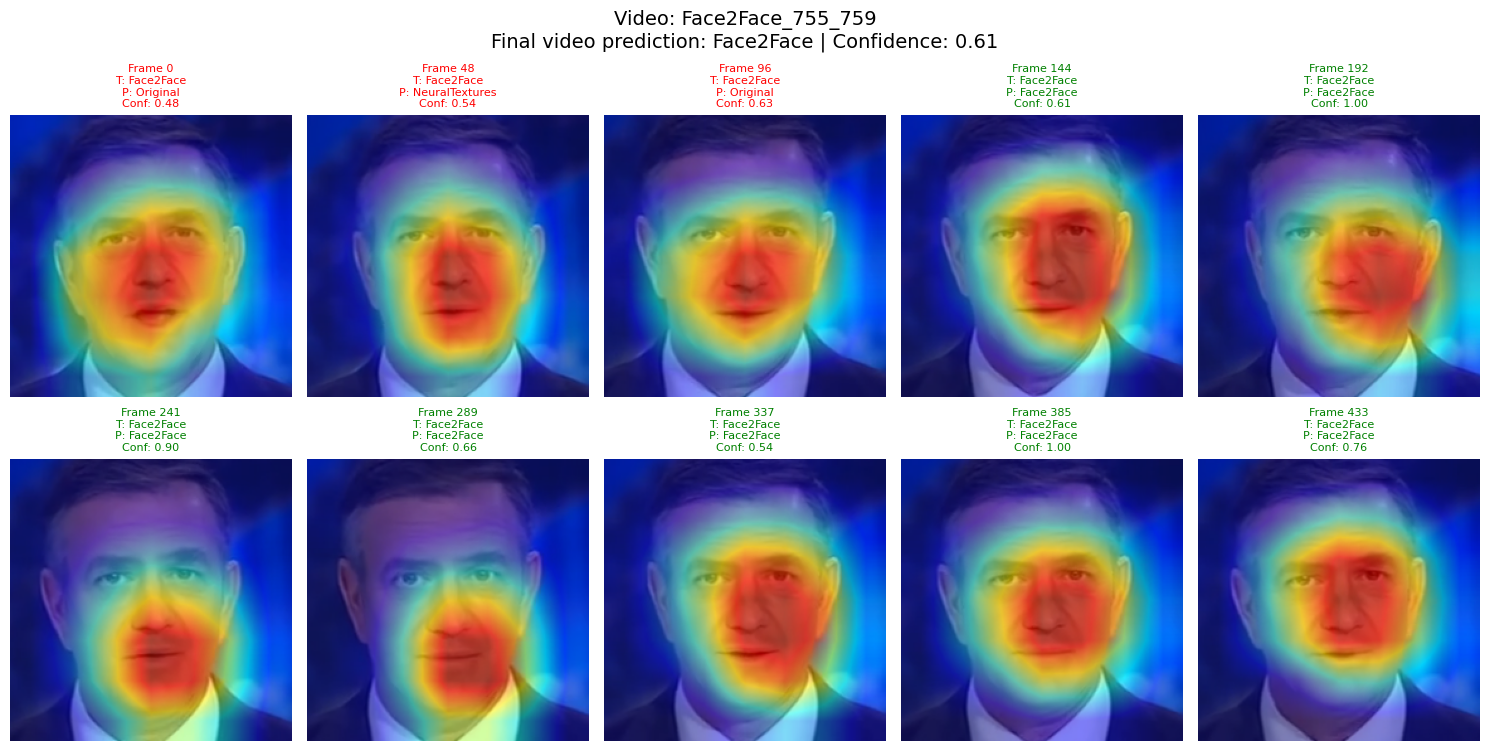

In [246]:
video_row, video_frames_df = show_video_gradcams(
    best_model,
    X_test,
    frame_predictions_df,
    video_predictions_df,
    CLASSES,
    seed=21,
    # true_class="Deepfakes",
    # video_key="000_003"
)

## t-SNE

In [76]:
def plot_tsne_multiclass(features, labels, class_names, title, seed=22):

    # standardize features
    features = StandardScaler().fit_transform(features)

    # dimensionality reduction with t-SNE
    tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=seed)
    features_2d = tsne.fit_transform(features)

    plt.figure(figsize=(8, 7))

    # plot one group of points for each class
    for class_index, class_name in enumerate(class_names):
        class_mask = labels == class_index
        plt.scatter(features_2d[class_mask, 0], features_2d[class_mask, 1], alpha=0.6, s=12, label=class_name)

    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.show()

In [77]:
# extract subsample from test set
def sample_test_loader_multiclass(data_module, class_names, samples_per_class=300, seed=22):

    rng = np.random.default_rng(seed)

    # create one list of images for each class
    images_by_class = {}

    for class_index in range(len(class_names)):
        images_by_class[class_index] = []

    dataloader = data_module.test_dataloader()

    # collect samples from the test dataloader
    for images, labels in dataloader:

        for image, label in zip(images, labels):
            label = int(label)

            if len(images_by_class[label]) < samples_per_class:
                images_by_class[label].append(image.numpy())

        # check if all classes have enough samples
        completed = True

        for class_index in range(len(class_names)):
            if len(images_by_class[class_index]) < samples_per_class:
                completed = False
        if completed:
            break

    # build X and y (balanced dataset)
    X = []
    y = []

    for class_index in range(len(class_names)):
        for image in images_by_class[class_index]:
            X.append(image)
            y.append(class_index)

    X = np.array(X)
    y = np.array(y)

    # shuffle samples
    indices = rng.permutation(len(X))

    return X[indices], y[indices]

In [ ]:
X_tsne, y_tsne = sample_test_loader_multiclass(data_module, CLASSES, samples_per_class=300)

In [78]:
from sklearn.decomposition import PCA

def extract_pixel_features(X, pca_components=50):

    # flatten each image into a 1D feature vector
    features = []
    for image in X:
        flattened_image = image.flatten()
        features.append(flattened_image)
    features = np.array(features)
    num_feat = features.shape[1]

    # reduce raw pixel features with PCA before t-SNE
    # 3×224×224 = 150528 -> 50
    pca = PCA(n_components=pca_components, random_state=22)
    features = pca.fit_transform(features)

    print(f"PCA: {X[0].size} → {pca_components} features\nExplained variance = {pca.explained_variance_ratio_.sum():.3f}")

    return features

In [79]:
def extract_fft_features(X, pca_components=50):

    features = []

    for image in X:

        image = unnormalize_image(image) # convert normalized tensor back to RGB image
        gray = np.mean(image, axis=2) # mean of channels to get grayscale

        fft = np.fft.fft2(gray)
        fft = np.fft.fftshift(fft)

        spectrum = np.log(np.abs(fft) + 1)
        features.append(spectrum.flatten())

    features = np.array(features)
    num_feat = features.shape[1]

    # 224×224 = 50176 -> 50
    pca = PCA(n_components=pca_components, random_state=22)
    features = pca.fit_transform(features)

    print(f"PCA: {num_feat} → {pca_components} features\nExplained variance = {pca.explained_variance_ratio_.sum():.3f}")

    return features

In [80]:
# Extract CNN embeddings from the trained ResNet18 model
def extract_cnn_features(model, X, pca_components=50, device=None): # ResNet18: 512 features

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model.eval()
    model.to(device)

    # remove the final classification layer and keep only the feature extractor
    feature_extractor = torch.nn.Sequential(*list(model.model.children())[:-1]).to(device)

    features = []

    with torch.no_grad():

        for i in range(0, len(X), 64): # process images in batches of 64

            batch = torch.tensor(X[i:i + 64], dtype=torch.float32).to(device)
            output = feature_extractor(batch) # extract 512-dimensional CNN embeddings
            output = output.view(output.size(0), -1) # flatten from (batch, 512, 1, 1) to (batch, 512)
            features.append(output.cpu().numpy())

    features = np.concatenate(features)
    num_feat = features.shape[1]

    # 512 -> 50
    pca = PCA(n_components=pca_components, random_state=22)
    features = pca.fit_transform(features)

    print(f"PCA: {num_feat} → {pca_components} features\nExplained variance = {pca.explained_variance_ratio_.sum():.3f}")

    return features

PCA: 150528 → 50 features
Explained variance = 0.861


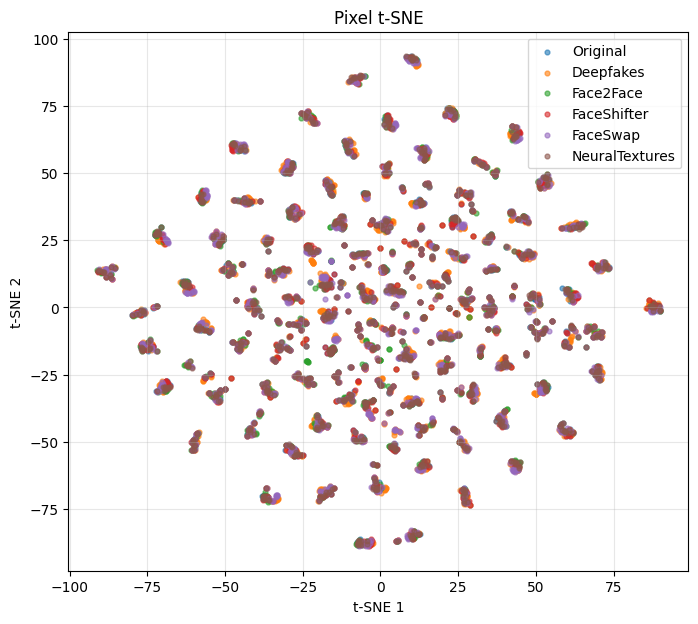

In [266]:
pixel_features = extract_pixel_features(X_tsne)
plot_tsne_multiclass(pixel_features, y_tsne, CLASSES, "Pixel t-SNE")

PCA: 50176 → 50 features
Explained variance = 0.478


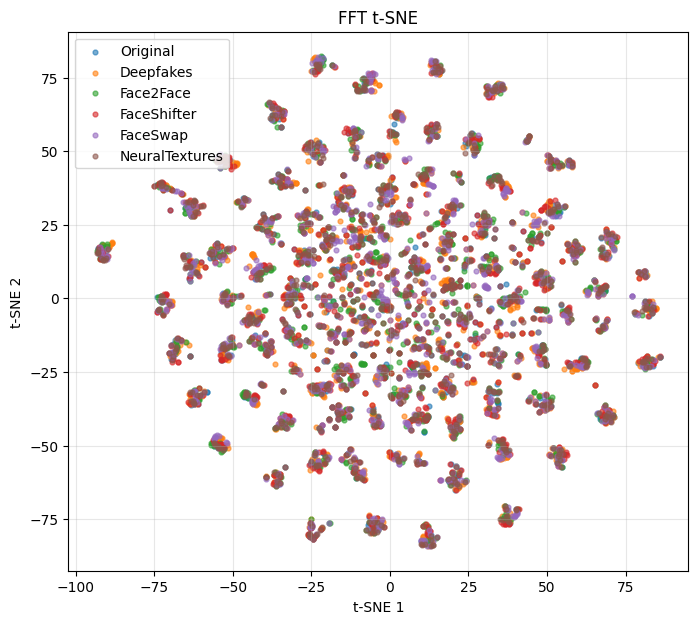

In [267]:
fft_features = extract_fft_features(X_tsne)
plot_tsne_multiclass(fft_features, y_tsne, CLASSES, "FFT t-SNE")

PCA: 512 → 50 features
Explained variance = 0.925


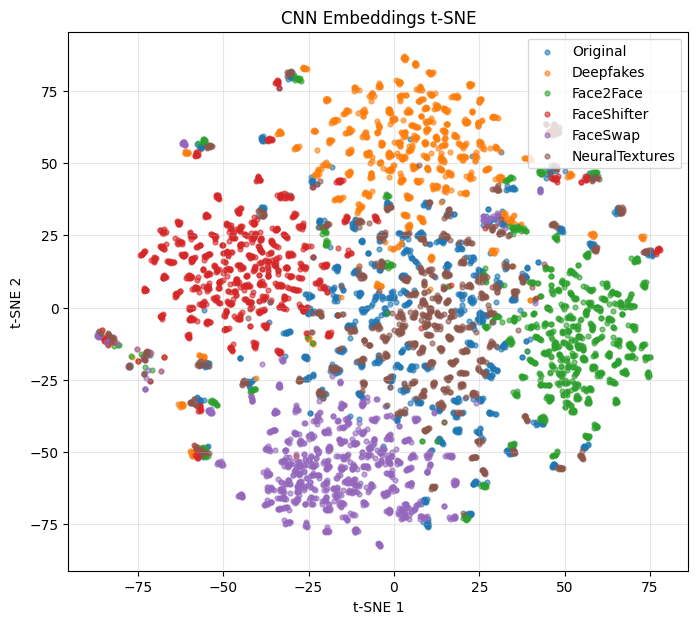

In [268]:
cnn_features = extract_cnn_features(best_model, X_tsne)
plot_tsne_multiclass(cnn_features, y_tsne, CLASSES, "CNN Embeddings t-SNE")

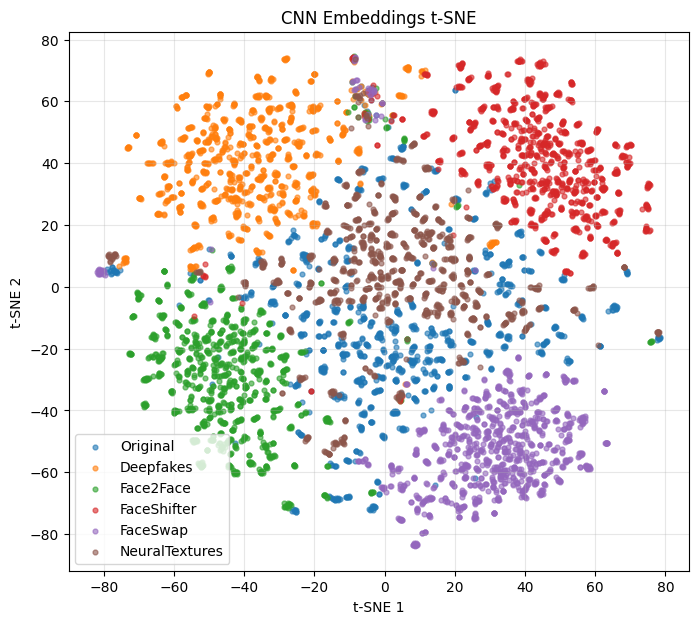

In [89]:
plot_tsne_multiclass(
    features=X_features_tsne,
    labels=y_tsne,
    class_names=CLASSES,
    title="CNN Embeddings t-SNE",
    seed=22
)